In [78]:
%pip install emoji
!python -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# imports

In [79]:
import re
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import emoji
import spacy
import joblib
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)

warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


# ─────────────────────────────────────────────────────────────
# STEP 1 — LOAD DATASET
# ─────────────────────────────────────────────────────────────

In [80]:
print("=" * 60)
print("STEP 1: Loading Dataset")
print("=" * 60)

df = pd.read_csv(r'D:\APU CLASS Sem -2\NLP\assignment_Q\assignment\IMDB Dataset.csv\IMDB Dataset.csv')

print(f"  Total reviews  : {len(df):,}")
print(f"  Columns        : {df.columns.tolist()}")
print(f"  Sentiment dist :\n{df['sentiment'].value_counts()}\n")

STEP 1: Loading Dataset
  Total reviews  : 50,000
  Columns        : ['review', 'sentiment']
  Sentiment dist :
sentiment
positive    25000
negative    25000
Name: count, dtype: int64



## Exploratory Data Analysis

In [81]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [83]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 418


In [84]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [85]:
df.shape

(49582, 2)

In [86]:
df.sentiment.value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

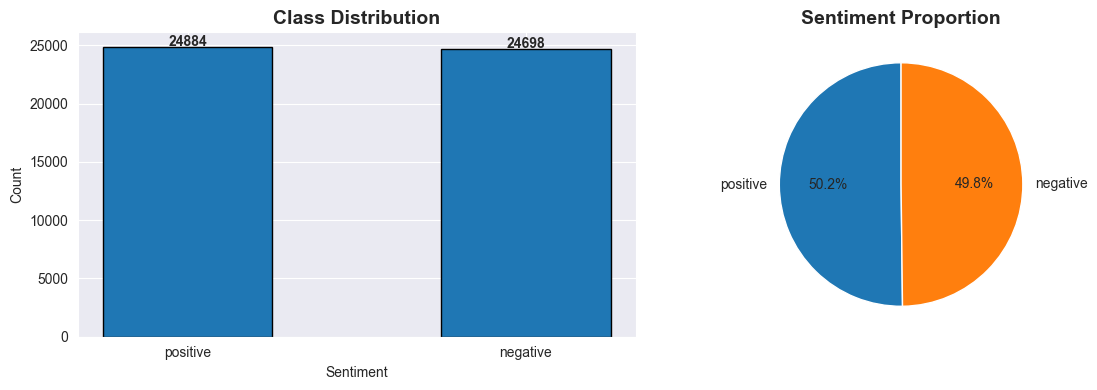


Class Counts:
Positive Reviews : 24884
Negative Reviews : 24698


In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['sentiment'].value_counts()

# Count plot
axes[0].bar(counts.index, counts.values, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Sentiment Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nClass Counts:")
print(f'Positive Reviews : {counts["positive"]}')
print(f'Negative Reviews : {counts["negative"]}')

## Text Preprocessing

In [88]:
num_map = {
        '0': 'zero', '1': 'one', '2': 'two', '3': 'three', '4': 'four',
        '5': 'five', '6': 'six', '7': 'seven', '8': 'eight', '9': 'nine'
    }
def text_to_numbers(text):
    return re.sub(r'\d', lambda m: num_map[m.group(0)], text)

slang_dict = {
    'omg' : 'oh my god',
    'lol' : 'laughing out loud',
    'tbh' : 'to be honest',
    'ngl' : 'not going to lie',
    'imo' : 'in my opinion',
    'fav' : 'favourite',
    'luv' : 'love',
    'gr8' : 'great',
    'b4'  : 'before',
    'cuz' : 'because'
}
def replace_slangs(text):
    words = text.split()
    return ' '.join([slang_dict.get(w, w) for w in words])

emoticon_dict = {
    ':)'  : 'happy',
    ':-)' : 'happy',
    ':D'  : 'very_happy',
    ':-D' : 'very_happy',
    ':('  : 'sad',
    ':-(' : 'sad',
    ';)'  : 'wink',
    ':P'  : 'playful',
    ':-P' : 'playful',
    ':/'  : 'skeptical',
    '>:(' : 'angry',
    ':|'  : 'neutral',
    '<3'  : 'love',
    'XD'  : 'laughing',
    ':o'  : 'surprised',
}

def replace_emoticons(text):
    for emoticon, meaning in emoticon_dict.items():
        text = text.replace(emoticon, f' {meaning} ')
    return text

def handle_negation(text):
    text = re.sub(r"\bwon't\b", "will not", text, flags=re.IGNORECASE)
    text = re.sub(r"\bcan't\b", "cannot",   text, flags=re.IGNORECASE)
    text = re.sub(r"n't\b", " not", text)
    negations = r"\b(not|no|never|neither|nor|hardly|barely|scarcely)\s+(\w+)"
    return re.sub(negations, lambda m: m.group(1) + '_' + m.group(2), text)

def handle_contrast(text):
    contrast_pattern = r'\b(but|however|yet|although|though|despite|nevertheless|still|actually|in fact|turned out)\b'
    parts = re.split(contrast_pattern, text, maxsplit=1, flags=re.IGNORECASE)
    if len(parts) >= 3:
        text = parts[0] + ' ' + parts[1] + ' ' + (parts[2] + ' ') * 3
    return text

def clean_text(text):
    text = replace_emoticons(text)                        # handles emoji
    text = emoji.demojize(text, delimiters=(" ", " "))    # handles emoji
    text = replace_slangs(text)
    text = text.lower()                                   # lowercase
    text = re.sub(r'<.*?>', ' ', text)                    # remove HTML tags
    text = re.sub(r'http\S+|www\S+', '', text)
    text = text_to_numbers(text)
    text = handle_contrast(text)                          # contrast FIRST
    text = handle_negation(text)                          # negation BEFORE symbol removal
    text = re.sub(r'(.)\1{2,}', r'\1', text)              # reduces any character repeated 3+ times to just 1

    text = re.sub(r'[^a-z_\s]', ' ', text)                # keep letters + underscore
    text = re.sub(r'\s+', ' ', text).strip()              # clean whitespace
    return text

df['clean_review'] = df['review'].apply(clean_text)
print(f"  BEFORE : {df['review'].iloc[0][:80]}...")
print(f"  AFTER  : {df['clean_review'].iloc[0][:80]}...")
print(f"  Done for {len(df):,} reviews")


  BEFORE : One of the other reviewers has mentioned that after watching just 1 Oz episode y...
  AFTER  : one of the other reviewers has mentioned that after watching just one oz episode...
  Done for 49,582 reviews


## Lemmatization

In [89]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

all_lemmatized_reviews = []

# nlp.pipe processes the 50,000 reviews in hyper-fast batches
for doc in nlp.pipe(df['clean_review'], batch_size=1000):

    # Extract the lemma for each word.
    # Optional bonus: We filter out punctuation and spaces to make your data even cleaner!
    lemmas = [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_space]

    # Save the list of lemmas
    all_lemmatized_reviews.append(lemmas)

# 4. Save the final results back to the dataframe
df['lemmatized_tokens'] = all_lemmatized_reviews

In [90]:
stop_words = spacy.lang.en.stop_words.STOP_WORDS.copy()
exceptions = [
    'not', 'no', 'cannot', 'neither', 'never', 'but', 'however',
    'although', 'though', 'except', 'yet', 'against', 'very',
    'too', 'really', 'almost', 'least', 'less', 'more', 'most', 'always']

for word in exceptions:
    stop_words.discard(word)

def remove_stop_words(token_list):
    filtered_words = [word for word in token_list if word.lower() not in stop_words]
    return ' '.join(filtered_words)

In [91]:
df['no_stops'] = df['lemmatized_tokens'].apply(remove_stop_words)
df['final_text_for_model'] = df['no_stops']

# Model 1 - Logistic regression sentiment


STEP 4: Train / Validation / Test Split (60 / 20 / 20)
label
Good    24884
Bad     24698
Name: count, dtype: int64
  Training set   : 29,749 (60%)
  Validation set : 9,916  (20%)
  Test set       : 9,917  (20%)

  Train labels:
label
Good    14930
Bad     14819
Name: count, dtype: int64

  Test labels:
label
Good    4977
Bad     4940
Name: count, dtype: int64

STEP 5: TF-IDF Feature Extraction
  Vocabulary size    : 30,000
  Train matrix shape : (29749, 30000)

STEP 6: Training Logistic Regression
  Training complete!

STEP 7: Validation Set Results

  Accuracy  : 0.8962  (89.62%)
  F1 Score  : 0.8962
  Precision : 0.8966
  Recall    : 0.8962

  Classification Report (Validation):
              precision    recall  f1-score   support

         Bad       0.91      0.88      0.89      4939
        Good       0.88      0.91      0.90      4977

    accuracy                           0.90      9916
   macro avg       0.90      0.90      0.90      9916
weighted avg       0.90      0.90    

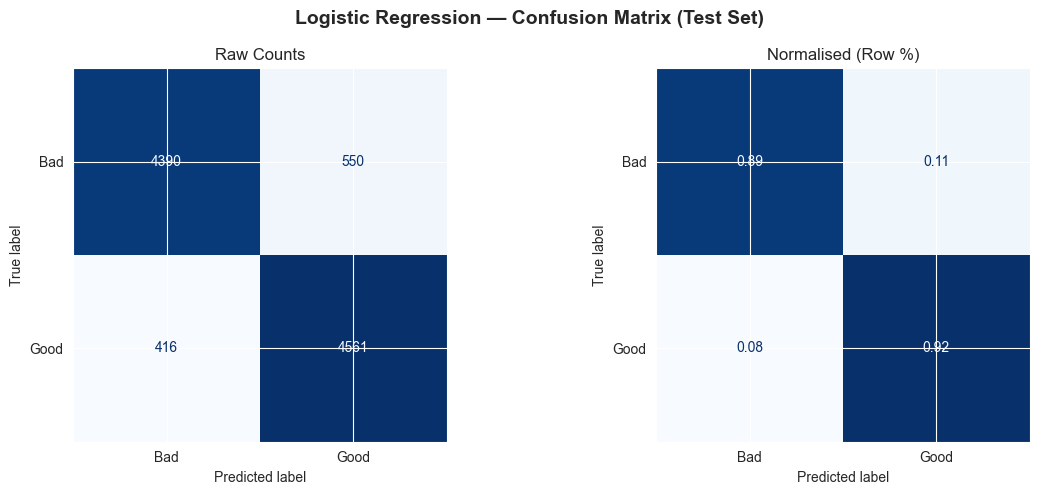

  Saved: confusion_matrix_LR.png

STEP 10: Top 15 Words Per Class


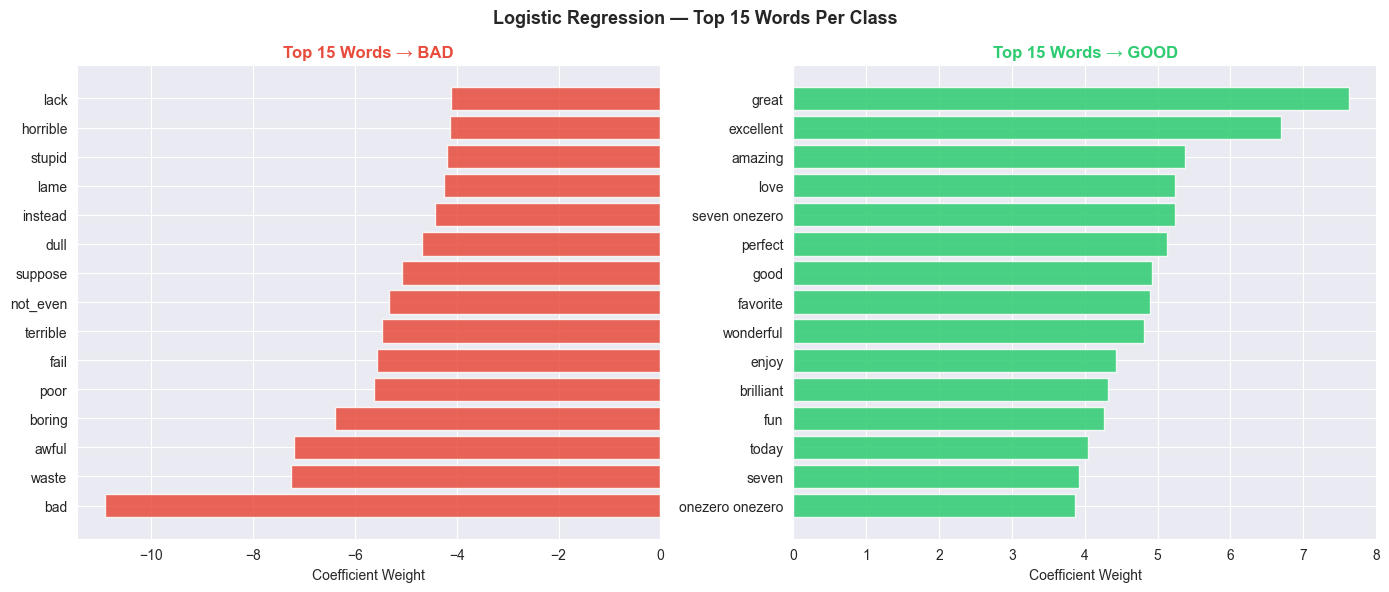

  Saved: top_features_LR.png

SUMMARY — Logistic Regression
  Validation Accuracy : 89.62%
  Test Accuracy       : 90.26%
  Test F1 (weighted)  : 0.9026
  Test Precision      : 0.9029
  Test Recall         : 0.9026


In [115]:
# ============================================================
# CT052-3-M-NLP | Logistic Regression Sentiment Classifier
# Dataset  : IMDB Movie Reviews (50,000 reviews)
# Classes  : Good / Bad
# Split    : 60% Train | 20% Val | 20% Test
# ============================================================



# ─────────────────────────────────────────────────────────────
# STEP 4 — TRAIN / VALIDATION / TEST SPLIT  (60 / 20 / 20)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: Train / Validation / Test Split (60 / 20 / 20)")
print("=" * 60)

df['label'] = df['sentiment'].map({'positive': 'Good', 'negative': 'Bad'})
print(df['label'].value_counts())

X = df['final_text_for_model']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"  Training set   : {len(X_train):,} ({len(X_train)/len(df)*100:.0f}%)")
print(f"  Validation set : {len(X_val):,}  ({len(X_val)/len(df)*100:.0f}%)")
print(f"  Test set       : {len(X_test):,}  ({len(X_test)/len(df)*100:.0f}%)")
print(f"\n  Train labels:\n{y_train.value_counts()}")
print(f"\n  Test labels:\n{y_test.value_counts()}")


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ─────────────────────────────────────────────────────────────
# STEP 5 — FEATURE EXTRACTION (TF-IDF)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: TF-IDF Feature Extraction")
print("=" * 60)

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Remove negation words from stop words so "not_good" etc. are kept
custom_stop_words = ENGLISH_STOP_WORDS - {
    'not', 'no', 'never', 'nor', 'neither', 'hardly', 'barely', 'scarcely'
}

tfidf = TfidfVectorizer(
    max_features = 30000,
    ngram_range  = (1, 2),
    min_df       = 3,
    max_df       = 0.95,
    sublinear_tf = True,
    stop_words   = list(custom_stop_words)
)

# Fit ONLY on training data — never on val or test
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"  Vocabulary size    : {len(tfidf.vocabulary_):,}")
print(f"  Train matrix shape : {X_train_tfidf.shape}")

# ─────────────────────────────────────────────────────────────
# STEP 6 — TRAIN LOGISTIC REGRESSION
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 6: Training Logistic Regression")
print("=" * 60)

lr_model = LogisticRegression(
    C            = 1.0,
    max_iter     = 500,
    solver       = 'lbfgs',
    random_state = 42,
    n_jobs       = -1
)

lr_model.fit(X_train_tfidf, y_train)
print("  Training complete!")

# ─────────────────────────────────────────────────────────────
# STEP 7 — VALIDATION RESULTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 7: Validation Set Results")
print("=" * 60)

val_preds = lr_model.predict(X_val_tfidf)

print(f"\n  Accuracy  : {accuracy_score(y_val, val_preds):.4f}  "
      f"({accuracy_score(y_val, val_preds)*100:.2f}%)")
print(f"  F1 Score  : {f1_score(y_val, val_preds, average='weighted'):.4f}")
print(f"  Precision : {precision_score(y_val, val_preds, average='weighted'):.4f}")
print(f"  Recall    : {recall_score(y_val, val_preds, average='weighted'):.4f}")
print(f"\n  Classification Report (Validation):")
print(classification_report(y_val, val_preds, target_names=['Bad', 'Good']))

# ─────────────────────────────────────────────────────────────
# STEP 8 — TEST SET RESULTS  (Final / Unseen Data)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 8: Test Set Results  (Final Evaluation)")
print("=" * 60)

test_preds = lr_model.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, test_preds)
test_f1  = f1_score(y_test, test_preds, average='weighted')
test_pre = precision_score(y_test, test_preds, average='weighted')
test_rec = recall_score(y_test, test_preds, average='weighted')

print(f"\n  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  F1 Score  : {test_f1:.4f}")
print(f"  Precision : {test_pre:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"\n  Classification Report (Test):")
print(classification_report(y_test, test_preds, target_names=['Bad', 'Good']))

# ─────────────────────────────────────────────────────────────
# STEP 9 — CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 9: Confusion Matrix")
print("=" * 60)

class_names = ['Bad', 'Good']
cm = confusion_matrix(y_test, test_preds, labels=class_names)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Logistic Regression — Confusion Matrix (Test Set)',
             fontsize=14, fontweight='bold')

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Raw Counts')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Normalised (Row %)')

plt.tight_layout()
plt.savefig('confusion_matrix_LR.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: confusion_matrix_LR.png")

# ─────────────────────────────────────────────────────────────
# STEP 10 — TOP FEATURES PER CLASS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 10: Top 15 Words Per Class")
print("=" * 60)

feature_names = tfidf.get_feature_names_out()
coef          = lr_model.coef_[0]   # single row for binary classification

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Logistic Regression — Top 15 Words Per Class',
             fontsize=13, fontweight='bold')

# Most negative coefficients → BAD reviews
bad_idx = np.argsort(coef)[:15]
axes[0].barh(feature_names[bad_idx], coef[bad_idx], color='#e74c3c', alpha=0.85)
axes[0].set_title('Top 15 Words → BAD', fontweight='bold', color='#e74c3c')
axes[0].set_xlabel('Coefficient Weight')

# Most positive coefficients → GOOD reviews
good_idx = np.argsort(coef)[-15:]
axes[1].barh(feature_names[good_idx], coef[good_idx], color='#2ecc71', alpha=0.85)
axes[1].set_title('Top 15 Words → GOOD', fontweight='bold', color='#2ecc71')
axes[1].set_xlabel('Coefficient Weight')

plt.tight_layout()
plt.savefig('top_features_LR.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: top_features_LR.png")

# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — Logistic Regression")
print("=" * 60)
print(f"  Validation Accuracy : {accuracy_score(y_val, val_preds)*100:.2f}%")
print(f"  Test Accuracy       : {test_acc*100:.2f}%")
print(f"  Test F1 (weighted)  : {test_f1:.4f}")
print(f"  Test Precision      : {test_pre:.4f}")
print(f"  Test Recall         : {test_rec:.4f}")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# STEP 12 — HYPERPARAMETER TUNING (Grid Search)
#
# We use a Pipeline so TF-IDF and LR are tuned together.
# Parameters tuned:
#   tfidf__max_features : vocabulary size
#   tfidf__ngram_range  : unigrams only vs unigrams + bigrams
#   lr__C               : regularisation (lower = stronger)
#
# StratifiedKFold (3-fold) ensures each fold has balanced
# Good/Bad classes. Total fits = 6 x 3 x 2 x 3 = 108 fits
# ─────────────────────────────────────────────────────────────


STEP 12: Hyperparameter Tuning — Grid Search CV
         Testing 108 combinations, please wait...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

  ✅ Grid Search Complete!
  Best CV F1 Score   : 0.8937
  Best Parameters    :
    lr__C                         : 5.0
    tfidf__max_features           : 30000
    tfidf__ngram_range            : (1, 2)

  --- Before vs After Tuning (Test Set) ---
  Metric              Before      After     Change
  -----------------------------------------------
  Accuracy            90.26%     90.41%     +0.15%
  F1 Score            0.9026     0.9041    +0.0015
  Precision           0.9029     0.9042    +0.0014
  Recall              0.9026     0.9041    +0.0015

  Classification Report (Tuned Model — Test Set):
              precision    recall  f1-score   support

         Bad       0.91      0.89      0.90      4940
        Good       0.90      0.91      0.91      4977

    accuracy                           0.90      9917
   macro avg   

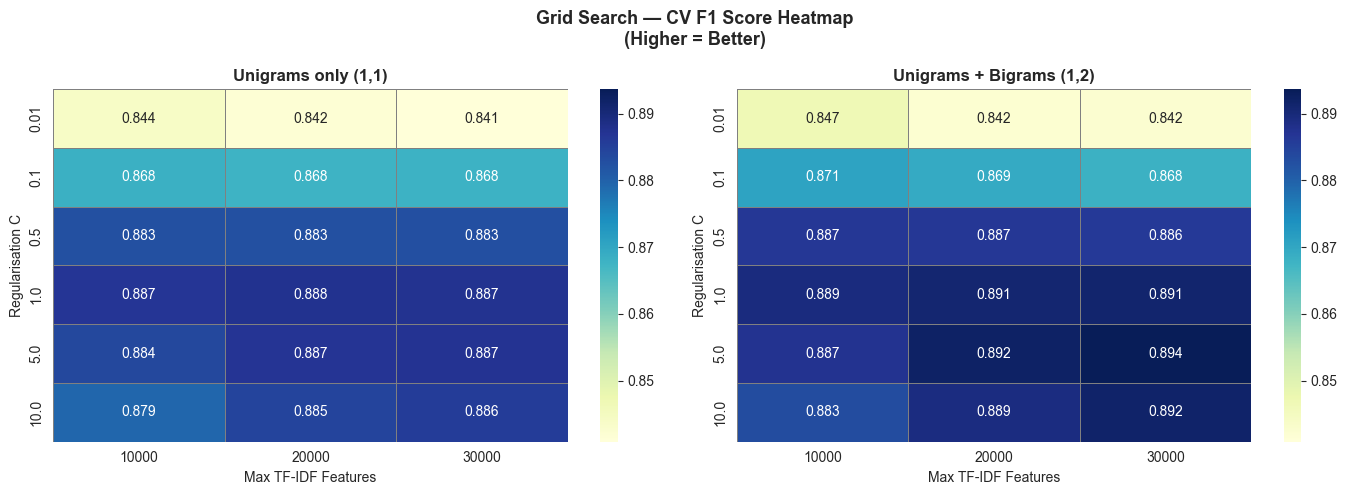

  Saved: gridsearch_heatmap_LR.png


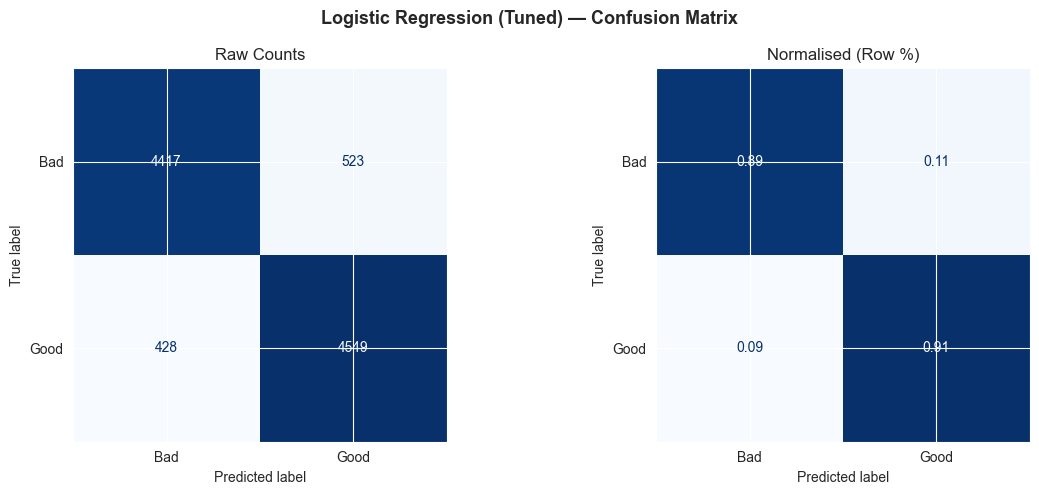

  Saved: confusion_matrix_LR_tuned.png

  ✅ Live prediction will now use the TUNED model


In [116]:
print("\n" + "=" * 60)
print("STEP 12: Hyperparameter Tuning — Grid Search CV")
print("         Testing 108 combinations, please wait...")
print("=" * 60)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Build pipeline — TF-IDF + LR as one unit
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df       = 3,
        max_df       = 0.95,
        sublinear_tf = True,
        stop_words   = list(custom_stop_words)
    )),
    ('lr', LogisticRegression(
        solver       = 'lbfgs',
        max_iter     = 500,
        random_state = 42,
        n_jobs       = -1
    ))
])

# Parameter grid — 6 x 3 x 2 = 36 combinations x 3 folds = 108 fits
param_grid = {
    'tfidf__max_features': [10000, 20000, 30000],
    'tfidf__ngram_range' : [(1, 1), (1, 2)],
    'lr__C'              : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv            = cv,
    scoring       = 'f1_weighted',
    n_jobs        = -1,
    verbose       = 1
)

grid_search.fit(X_train, y_train)

print(f"\n  ✅ Grid Search Complete!")
print(f"  Best CV F1 Score   : {grid_search.best_score_:.4f}")
print(f"  Best Parameters    :")
for param, value in grid_search.best_params_.items():
    print(f"    {param:<30}: {value}")

# ─── Evaluate best model on test set ─────────────────────────
best_model   = grid_search.best_estimator_
tuned_preds  = best_model.predict(X_test)

tuned_acc = accuracy_score(y_test, tuned_preds)
tuned_f1  = f1_score(y_test, tuned_preds, average='weighted')
tuned_pre = precision_score(y_test, tuned_preds, average='weighted')
tuned_rec = recall_score(y_test, tuned_preds, average='weighted')

print(f"\n  --- Before vs After Tuning (Test Set) ---")
print(f"  {'Metric':<15} {'Before':>10} {'After':>10} {'Change':>10}")
print(f"  {'-'*47}")
print(f"  {'Accuracy':<15} {test_acc*100:>9.2f}% {tuned_acc*100:>9.2f}% {(tuned_acc-test_acc)*100:>+9.2f}%")
print(f"  {'F1 Score':<15} {test_f1:>10.4f} {tuned_f1:>10.4f} {tuned_f1-test_f1:>+10.4f}")
print(f"  {'Precision':<15} {test_pre:>10.4f} {tuned_pre:>10.4f} {tuned_pre-test_pre:>+10.4f}")
print(f"  {'Recall':<15} {test_rec:>10.4f} {tuned_rec:>10.4f} {tuned_rec-test_rec:>+10.4f}")

print(f"\n  Classification Report (Tuned Model — Test Set):")
print(classification_report(y_test, tuned_preds, target_names=['Bad', 'Good']))

# ─── Figure: Grid Search Heatmap ─────────────────────────────
import pandas as pd
cv_results = pd.DataFrame(grid_search.cv_results_)

# Plot one heatmap per ngram_range
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Grid Search — CV F1 Score Heatmap\n(Higher = Better)',
             fontsize=13, fontweight='bold')

ngram_labels = {(1, 1): 'Unigrams only (1,1)', (1, 2): 'Unigrams + Bigrams (1,2)'}

for ax, ngram in zip(axes, [(1, 1), (1, 2)]):
    mask = cv_results['param_tfidf__ngram_range'].apply(lambda x: x == ngram)
    subset = cv_results[mask].copy()
    subset['C']           = subset['param_lr__C'].astype(float)
    subset['max_features']= subset['param_tfidf__max_features'].astype(int)

    pivot = subset.pivot_table(
        values  = 'mean_test_score',
        index   = 'C',
        columns = 'max_features'
    )

    import seaborn as sns
    sns.heatmap(
        pivot, annot=True, fmt='.3f',
        cmap='YlGnBu', ax=ax,
        linewidths=0.5, linecolor='gray',
        vmin=cv_results['mean_test_score'].min(),
        vmax=cv_results['mean_test_score'].max()
    )
    ax.set_title(ngram_labels[ngram], fontweight='bold')
    ax.set_xlabel('Max TF-IDF Features')
    ax.set_ylabel('Regularisation C')

plt.tight_layout()
plt.savefig('gridsearch_heatmap_LR.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: gridsearch_heatmap_LR.png")

# ─── Confusion matrix for tuned model ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Logistic Regression (Tuned) — Confusion Matrix',
             fontsize=13, fontweight='bold')

cm_tuned = confusion_matrix(y_test, tuned_preds, labels=['Bad', 'Good'])
ConfusionMatrixDisplay(cm_tuned, display_labels=['Bad', 'Good']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Raw Counts')

cm_tuned_norm = cm_tuned.astype('float') / cm_tuned.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(cm_tuned_norm.round(2), display_labels=['Bad', 'Good']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Normalised (Row %)')

plt.tight_layout()
plt.savefig('confusion_matrix_LR_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: confusion_matrix_LR_tuned.png")

# Update live prediction to use tuned model
print(f"\n  ✅ Live prediction will now use the TUNED model")

# STEP 11 — LIVE PREDICTION
#   Write your own review and the model will predict Good / Bad

In [121]:
print("\n" + "=" * 60)
print("STEP 11: Live Prediction — Try Your Own Review!")
print("         Type 'quit' to exit")
print("=" * 60)

def predict_review(review_text):
    cleaned = clean_text(review_text)
    vector  = tfidf.transform([cleaned])
    pred    = lr_model.predict(vector)[0]
    proba   = lr_model.predict_proba(vector)[0]
    classes = lr_model.classes_

    print(f"\n  Review     : {review_text[:80]}{'...' if len(review_text) > 80 else ''}")
    print(f"  Prediction : {'✅ GOOD' if pred == 'Good' else '❌ BAD'}")
    print(f"  Confidence :")
    for cls, prob in zip(classes, proba):
        bar = '█' * int(prob * 30)
        print(f"    {cls:<6}: {prob*100:5.1f}%  {bar}")

while True:
    print()
    user_input = input("Enter a movie review (or 'quit' to exit): ").strip()
    if user_input.lower() == 'quit':
        print("\n  Goodbye!")
        break
    if not user_input:
        print("  Please enter a review.")
        continue
    predict_review(user_input)


STEP 11: Live Prediction — Try Your Own Review!
         Type 'quit' to exit


  Review     : this is good movie
  Prediction : ✅ GOOD
  Confidence :
    Bad   :  13.8%  ████
    Good  :  86.2%  █████████████████████████


  Goodbye!


# ╔════════════════════════════════════════════════════════════╗
# ║          NAIVE BAYES MODEL                                 ║
# ╚════════════════════════════════════════════════════════════╝



  NAIVE BAYES MODEL

NB STEP 2: TF-IDF Feature Extraction for Naive Bayes
  Vocabulary size    : 30,000
  Train matrix shape : (29749, 30000)

NB STEP 3: Training Complement Naive Bayes
  Training complete!

NB STEP 4: Validation Set Results

  Accuracy  : 0.8759  (87.59%)
  F1 Score  : 0.8758
  Precision : 0.8761
  Recall    : 0.8759

  Classification Report (Validation):
              precision    recall  f1-score   support

         Bad       0.88      0.86      0.87      4939
        Good       0.87      0.89      0.88      4977

    accuracy                           0.88      9916
   macro avg       0.88      0.88      0.88      9916
weighted avg       0.88      0.88      0.88      9916


NB STEP 5: Test Set Results  (Final Evaluation)

  Accuracy  : 0.8771  (87.71%)
  F1 Score  : 0.8771
  Precision : 0.8772
  Recall    : 0.8771

  Classification Report (Test):
              precision    recall  f1-score   support

         Bad       0.88      0.87      0.88      4940
        G

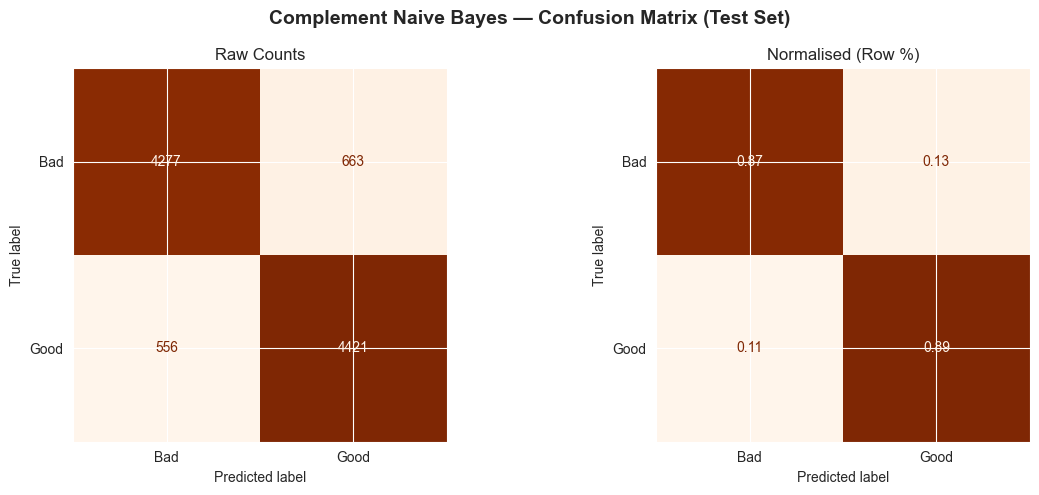

  Saved: confusion_matrix_NB.png

NB STEP 7: Top 15 Words Per Class


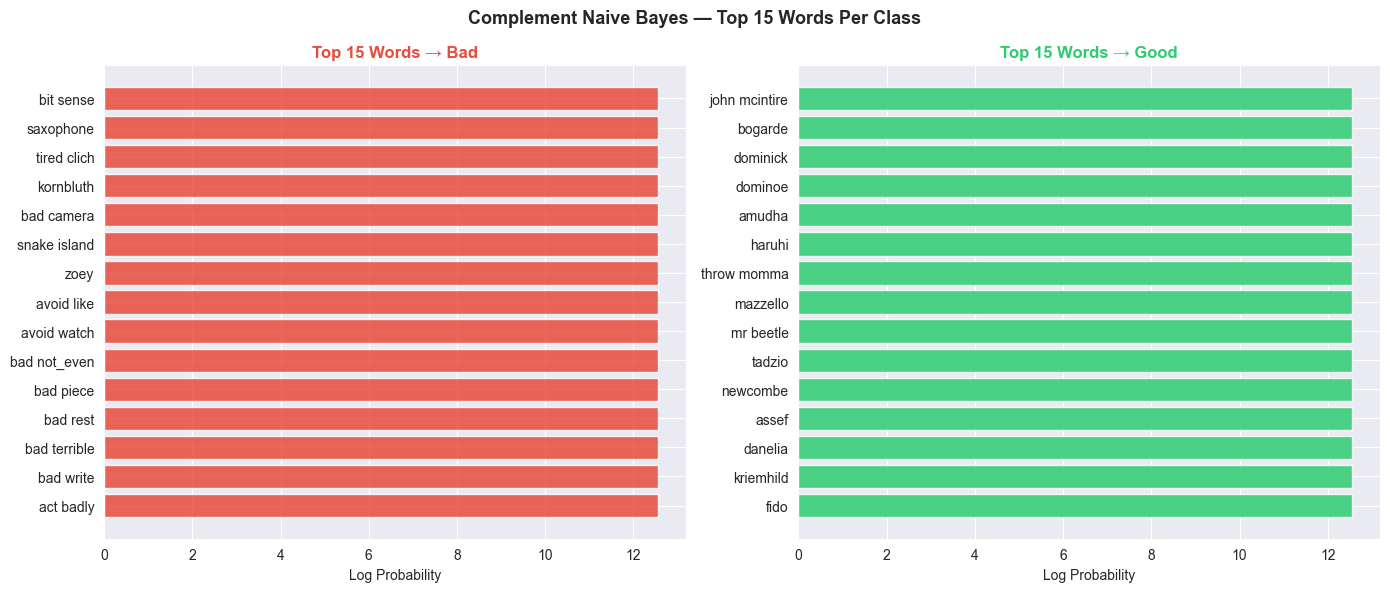

  Saved: top_features_NB.png

NB STEP 8: Hyperparameter Tuning — Grid Search CV
         Testing 90 combinations, please wait...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

  ✅ Grid Search Complete!
  Best CV F1 Score : 0.8725
  Best Parameters  :
    complementnb__alpha                : 1.0
    tfidf__max_features                : 30000
    tfidf__ngram_range                 : (1, 2)

  --- Before vs After Tuning (Test Set) ---
  Metric              Before      After     Change
  -----------------------------------------------
  Accuracy            87.71%     87.82%     +0.11%
  F1 Score            0.8771     0.8782    +0.0011
  Precision           0.8772     0.8783    +0.0011
  Recall              0.8771     0.8782    +0.0011

  Classification Report (Tuned NB — Test Set):
              precision    recall  f1-score   support

         Bad       0.89      0.87      0.88      4940
        Good       0.87      0.89      0.88      4977

    accuracy                    

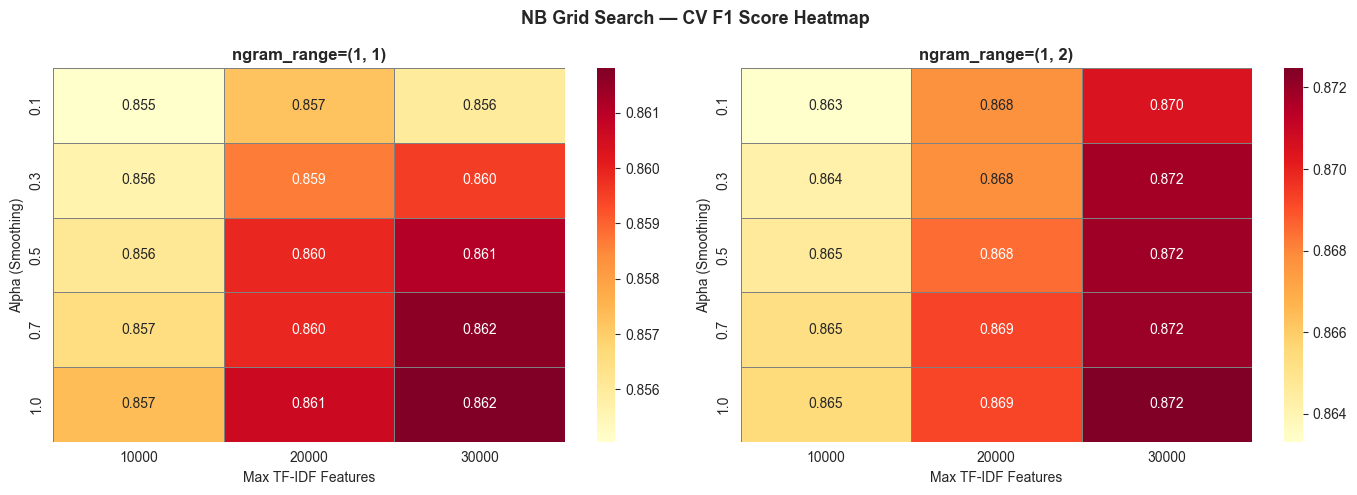

  Saved: gridsearch_heatmap_NB.png

NB STEP 9: Model Comparison — LR vs Naive Bayes


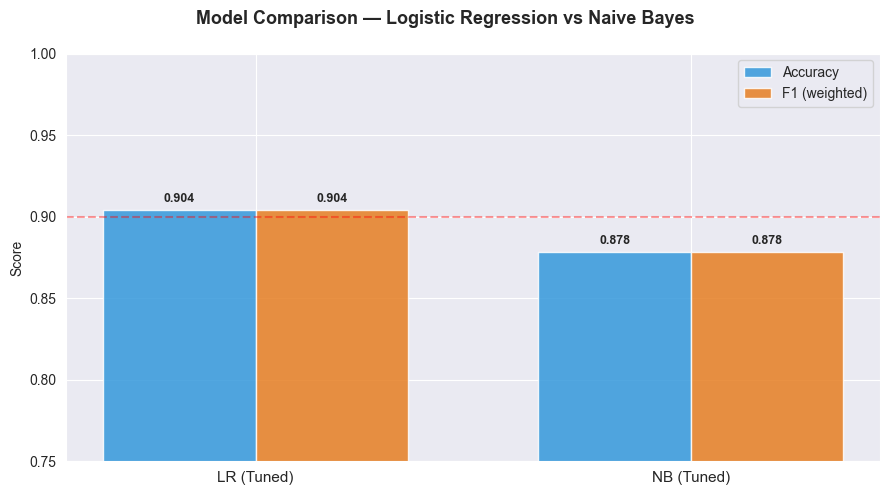

  Saved: comparison_LR_vs_NB.png


In [117]:
from sklearn.naive_bayes import ComplementNB, MultinomialNB

# ─────────────────────────────────────────────────────────────
# NB STEP 1 — WHY COMPLEMENT NAIVE BAYES?
#
# Standard Multinomial NB works well on balanced datasets.
# Complement NB (CNB) is specifically designed for text
# classification — it learns from what a class is NOT,
# which makes it more robust and accurate on sentiment tasks.
# Paper: Rennie et al. (2003) showed CNB consistently
# outperforms Multinomial NB on text datasets.
# ─────────────────────────────────────────────────────────────
print("\n")
print("=" * 60)
print("  NAIVE BAYES MODEL")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
# NB STEP 2 — FEATURE EXTRACTION FOR NAIVE BAYES
#
# NB requires NON-NEGATIVE values in feature matrix.
# TF-IDF with sublinear_tf=True always gives non-negative
# values so it works perfectly with NB.

# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("NB STEP 2: TF-IDF Feature Extraction for Naive Bayes")
print("=" * 60)

tfidf_nb = TfidfVectorizer(
    max_features = 30000,
    ngram_range  = (1, 2),
    min_df       = 3,
    max_df       = 0.95,
    sublinear_tf = True,
    stop_words   = list(custom_stop_words)
)

# Fit ONLY on training data
X_train_nb = tfidf_nb.fit_transform(X_train)
X_val_nb   = tfidf_nb.transform(X_val)
X_test_nb  = tfidf_nb.transform(X_test)

print(f"  Vocabulary size    : {len(tfidf_nb.vocabulary_):,}")
print(f"  Train matrix shape : {X_train_nb.shape}")

# ─────────────────────────────────────────────────────────────
# NB STEP 3 — TRAIN COMPLEMENT NAIVE BAYES
#
# alpha : Laplace smoothing — prevents zero probability for
#         unseen words. 0.5 works better than 1.0 for text.
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("NB STEP 3: Training Complement Naive Bayes")
print("=" * 60)

nb_model = ComplementNB(alpha=0.5)
nb_model.fit(X_train_nb, y_train)
print("  Training complete!")

# ─────────────────────────────────────────────────────────────
# NB STEP 4 — VALIDATION RESULTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("NB STEP 4: Validation Set Results")
print("=" * 60)

nb_val_preds = nb_model.predict(X_val_nb)

nb_val_acc = accuracy_score(y_val, nb_val_preds)
nb_val_f1  = f1_score(y_val, nb_val_preds, average='weighted')
nb_val_pre = precision_score(y_val, nb_val_preds, average='weighted')
nb_val_rec = recall_score(y_val, nb_val_preds, average='weighted')

print(f"\n  Accuracy  : {nb_val_acc:.4f}  ({nb_val_acc*100:.2f}%)")
print(f"  F1 Score  : {nb_val_f1:.4f}")
print(f"  Precision : {nb_val_pre:.4f}")
print(f"  Recall    : {nb_val_rec:.4f}")
print(f"\n  Classification Report (Validation):")
print(classification_report(y_val, nb_val_preds, target_names=['Bad', 'Good']))

# ─────────────────────────────────────────────────────────────
# NB STEP 5 — TEST SET RESULTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("NB STEP 5: Test Set Results  (Final Evaluation)")
print("=" * 60)

nb_test_preds = nb_model.predict(X_test_nb)

nb_test_acc = accuracy_score(y_test, nb_test_preds)
nb_test_f1  = f1_score(y_test, nb_test_preds, average='weighted')
nb_test_pre = precision_score(y_test, nb_test_preds, average='weighted')
nb_test_rec = recall_score(y_test, nb_test_preds, average='weighted')

print(f"\n  Accuracy  : {nb_test_acc:.4f}  ({nb_test_acc*100:.2f}%)")
print(f"  F1 Score  : {nb_test_f1:.4f}")
print(f"  Precision : {nb_test_pre:.4f}")
print(f"  Recall    : {nb_test_rec:.4f}")
print(f"\n  Classification Report (Test):")
print(classification_report(y_test, nb_test_preds, target_names=['Bad', 'Good']))

# ─────────────────────────────────────────────────────────────
# NB STEP 6 — CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("NB STEP 6: Confusion Matrix")
print("=" * 60)

nb_cm = confusion_matrix(y_test, nb_test_preds, labels=['Bad', 'Good'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Complement Naive Bayes — Confusion Matrix (Test Set)',
             fontsize=14, fontweight='bold')

ConfusionMatrixDisplay(nb_cm, display_labels=['Bad', 'Good']).plot(
    ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Raw Counts')

nb_cm_norm = nb_cm.astype('float') / nb_cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(nb_cm_norm.round(2), display_labels=['Bad', 'Good']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Normalised (Row %)')

plt.tight_layout()
plt.savefig('confusion_matrix_NB.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: confusion_matrix_NB.png")

# ─────────────────────────────────────────────────────────────
# NB STEP 7 — TOP FEATURES PER CLASS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("NB STEP 7: Top 15 Words Per Class")
print("=" * 60)

nb_features  = tfidf_nb.get_feature_names_out()
nb_log_probs = nb_model.feature_log_prob_   # shape: (n_classes, n_features)
nb_classes   = nb_model.classes_            # ['Bad', 'Good']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Complement Naive Bayes — Top 15 Words Per Class',
             fontsize=13, fontweight='bold')

nb_colors = {'Bad': '#e74c3c', 'Good': '#2ecc71'}

for ax, (cls, log_prob_row) in zip(axes, zip(nb_classes, nb_log_probs)):
    top_idx   = np.argsort(log_prob_row)[-15:]
    top_words = nb_features[top_idx]
    top_vals  = log_prob_row[top_idx]
    ax.barh(top_words, top_vals,
            color=nb_colors.get(cls, '#3498db'), alpha=0.85)
    ax.set_title(f'Top 15 Words → {cls}', fontweight='bold',
                 color=nb_colors.get(cls, '#3498db'))
    ax.set_xlabel('Log Probability')

plt.tight_layout()
plt.savefig('top_features_NB.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: top_features_NB.png")

# ─────────────────────────────────────────────────────────────
# NB STEP 8 — HYPERPARAMETER TUNING (Grid Search)
#
# Parameters tuned:
#   tfidf__max_features : vocabulary size
#   tfidf__ngram_range  : unigrams vs unigrams+bigrams
#   complementnb__alpha : Laplace smoothing strength
#
# Total: 3 x 2 x 5 = 30 combinations x 3 folds = 90 fits
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("NB STEP 8: Hyperparameter Tuning — Grid Search CV")
print("         Testing 90 combinations, please wait...")
print("=" * 60)

nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df       = 3,
        max_df       = 0.95,
        sublinear_tf = True,
        stop_words   = list(custom_stop_words)
    )),
    ('complementnb', ComplementNB())
])

nb_param_grid = {
    'tfidf__max_features'  : [10000, 20000, 30000],
    'tfidf__ngram_range'   : [(1, 1), (1, 2)],
    'complementnb__alpha'  : [0.1, 0.3, 0.5, 0.7, 1.0]
}

nb_grid_search = GridSearchCV(
    nb_pipeline,
    nb_param_grid,
    cv      = cv,
    scoring = 'f1_weighted',
    n_jobs  = -1,
    verbose = 1
)

nb_grid_search.fit(X_train, y_train)

print(f"\n  ✅ Grid Search Complete!")
print(f"  Best CV F1 Score : {nb_grid_search.best_score_:.4f}")
print(f"  Best Parameters  :")
for param, value in nb_grid_search.best_params_.items():
    print(f"    {param:<35}: {value}")

# Evaluate best NB model on test set
best_nb_model  = nb_grid_search.best_estimator_
nb_tuned_preds = best_nb_model.predict(X_test)

nb_tuned_acc = accuracy_score(y_test, nb_tuned_preds)
nb_tuned_f1  = f1_score(y_test, nb_tuned_preds, average='weighted')
nb_tuned_pre = precision_score(y_test, nb_tuned_preds, average='weighted')
nb_tuned_rec = recall_score(y_test, nb_tuned_preds, average='weighted')

print(f"\n  --- Before vs After Tuning (Test Set) ---")
print(f"  {'Metric':<15} {'Before':>10} {'After':>10} {'Change':>10}")
print(f"  {'-'*47}")
print(f"  {'Accuracy':<15} {nb_test_acc*100:>9.2f}% {nb_tuned_acc*100:>9.2f}% "
      f"{(nb_tuned_acc-nb_test_acc)*100:>+9.2f}%")
print(f"  {'F1 Score':<15} {nb_test_f1:>10.4f} {nb_tuned_f1:>10.4f} "
      f"{nb_tuned_f1-nb_test_f1:>+10.4f}")
print(f"  {'Precision':<15} {nb_test_pre:>10.4f} {nb_tuned_pre:>10.4f} "
      f"{nb_tuned_pre-nb_test_pre:>+10.4f}")
print(f"  {'Recall':<15} {nb_test_rec:>10.4f} {nb_tuned_rec:>10.4f} "
      f"{nb_tuned_rec-nb_test_rec:>+10.4f}")

print(f"\n  Classification Report (Tuned NB — Test Set):")
print(classification_report(y_test, nb_tuned_preds, target_names=['Bad', 'Good']))

# Heatmap for NB grid search
nb_cv_results = pd.DataFrame(nb_grid_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NB Grid Search — CV F1 Score Heatmap',
             fontsize=13, fontweight='bold')

for ax, ngram in zip(axes, [(1, 1), (1, 2)]):
    mask   = nb_cv_results['param_tfidf__ngram_range'].apply(lambda x: x == ngram)
    subset = nb_cv_results[mask].copy()
    subset['alpha']        = subset['param_complementnb__alpha'].astype(float)
    subset['max_features'] = subset['param_tfidf__max_features'].astype(int)

    pivot = subset.pivot_table(
        values  = 'mean_test_score',
        index   = 'alpha',
        columns = 'max_features'
    )
    import seaborn as sns
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                ax=ax, linewidths=0.5, linecolor='gray')
    ax.set_title(f'ngram_range={ngram}', fontweight='bold')
    ax.set_xlabel('Max TF-IDF Features')
    ax.set_ylabel('Alpha (Smoothing)')

plt.tight_layout()
plt.savefig('gridsearch_heatmap_NB.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: gridsearch_heatmap_NB.png")

# ─────────────────────────────────────────────────────────────
# NB STEP 9 — COMPARE LR vs NB
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("NB STEP 9: Model Comparison — LR vs Naive Bayes")
print("=" * 60)

models      = ['LR (Tuned)', 'NB (Tuned)']
accuracies  = [tuned_acc,    nb_tuned_acc]
f1_scores   = [tuned_f1,     nb_tuned_f1]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Model Comparison — Logistic Regression vs Naive Bayes',
             fontsize=13, fontweight='bold')

bars1 = ax.bar(x - width/2, accuracies, width,
               label='Accuracy', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores,  width,
               label='F1 (weighted)', color='#e67e22', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel('Score')
ax.legend()
ax.axhline(0.90, color='red', linestyle='--', alpha=0.4, label='90% line')

plt.tight_layout()
plt.savefig('comparison_LR_vs_NB.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: comparison_LR_vs_NB.png")

# ─────────────────────────────────────────────────────────────
# NB STEP 10 — LIVE PREDICTION (NB)
# ─────────────────────────────────────────────────────────────

In [119]:
print("\n" + "=" * 60)
print("NB STEP 10: Live Prediction — Naive Bayes")
print("            Type 'quit' to exit")
print("=" * 60)

def predict_nb(review_text):
    cleaned = clean_text(review_text)
    pred    = best_nb_model.predict([cleaned])[0]
    proba   = best_nb_model.predict_proba([cleaned])[0]
    classes = best_nb_model.classes_

    print(f"\n  Review     : {review_text[:80]}{'...' if len(review_text) > 80 else ''}")
    print(f"  [NB] Prediction : {'✅ GOOD' if pred == 'Good' else '❌ BAD'}")
    print(f"  Confidence :")
    for cls, prob in zip(classes, proba):
        bar = '█' * int(prob * 30)
        print(f"    {cls:<6}: {prob*100:5.1f}%  {bar}")

while True:
    print()
    user_input = input("Enter a review for NB (or 'quit' to exit): ").strip()
    if user_input.lower() == 'quit':
        print("\n  Goodbye!")
        break
    if not user_input:
        print("  Please enter a review.")
        continue
    predict_nb(user_input)


NB STEP 10: Live Prediction — Naive Bayes
            Type 'quit' to exit


  Review     : this movie is good
  [NB] Prediction : ✅ GOOD
  Confidence :
    Bad   :  43.9%  █████████████
    Good  :  56.1%  ████████████████


  Goodbye!


# ╔══════════════════════════════════════════════════════════╗
# ║              MODEL 3 — LINEAR SVM                       ║
# ╚══════════════════════════════════════════════════════════╝



  LINEAR SVM MODEL

SVM STEP 2: TF-IDF Feature Extraction for Linear SVM
  Vocabulary size    : 30,000
  Train matrix shape : (29749, 30000)

SVM STEP 3: Training Linear SVM
  Training complete!

SVM STEP 4: Validation Set Results

  Accuracy  : 0.8993  (89.93%)
  F1 Score  : 0.8992
  Precision : 0.8994
  Recall    : 0.8993

  Classification Report (Validation):
              precision    recall  f1-score   support

         Bad       0.91      0.89      0.90      4939
        Good       0.89      0.91      0.90      4977

    accuracy                           0.90      9916
   macro avg       0.90      0.90      0.90      9916
weighted avg       0.90      0.90      0.90      9916


SVM STEP 5: Test Set Results  (Final Evaluation)

  Accuracy  : 0.9048  (90.48%)
  F1 Score  : 0.9048
  Precision : 0.9049
  Recall    : 0.9048

  Classification Report (Test):
              precision    recall  f1-score   support

         Bad       0.91      0.90      0.90      4940
        Good       

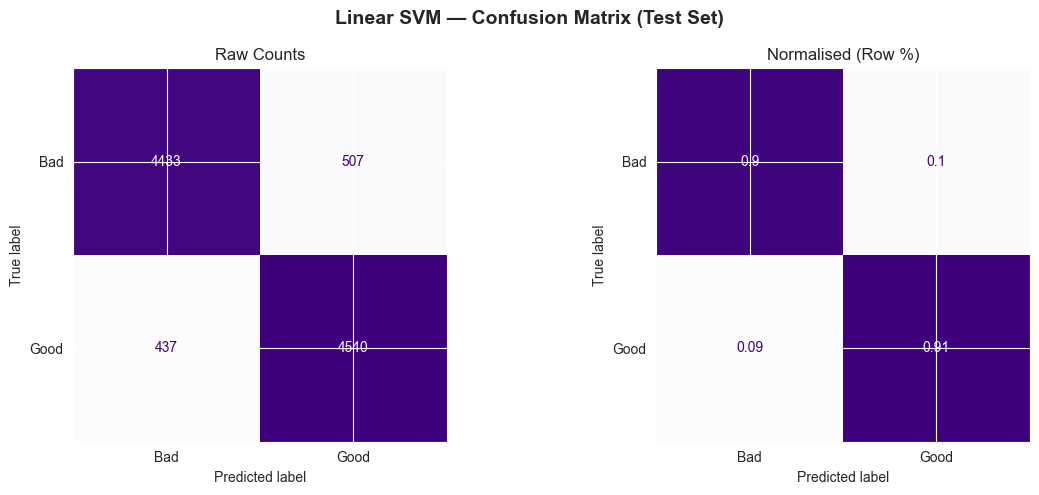

  Saved: confusion_matrix_SVM.png

SVM STEP 7: Top 15 Words Per Class


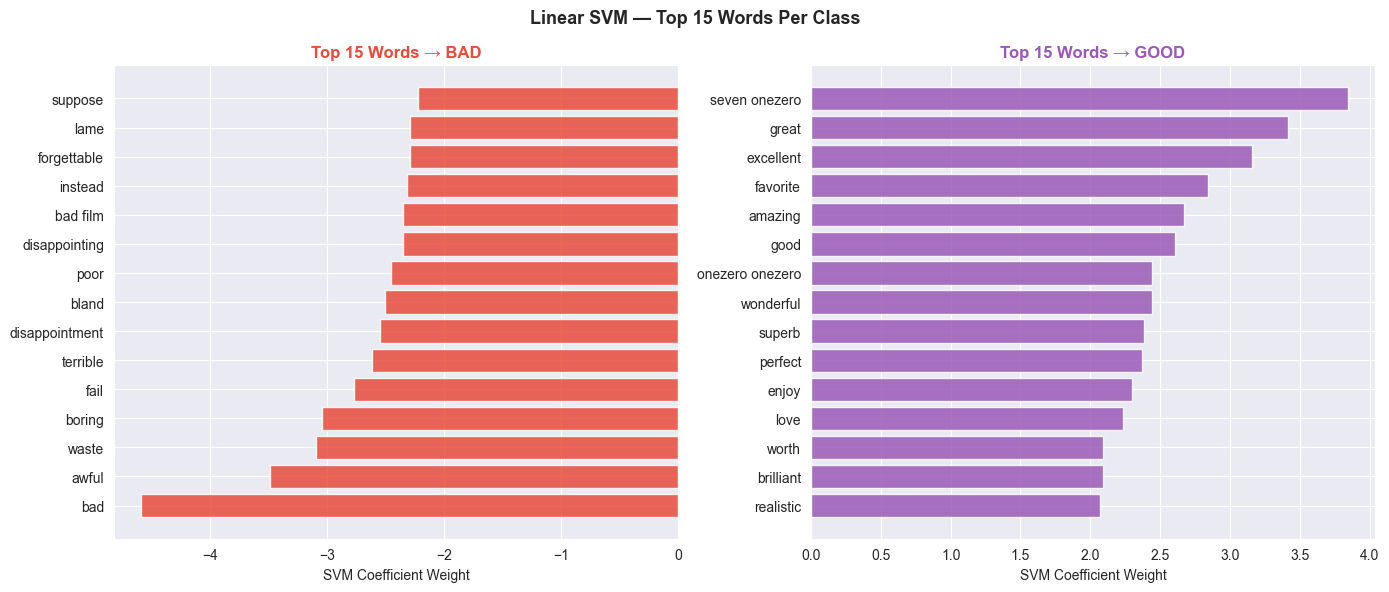

  Saved: top_features_SVM.png

SVM STEP 8: Hyperparameter Tuning — Grid Search CV
            90 combinations x 3 folds, please wait...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

  ✅ Best CV F1 : 0.8940
  Best Params  :
    svm__estimator__C                  : 1.0
    tfidf__max_features                : 30000
    tfidf__ngram_range                 : (1, 2)

  Before vs After Tuning (Test Set):
  Metric           Before      After     Change
  --------------------------------------------
  Accuracy         90.48%     90.48%     +0.00%
  F1               0.9048     0.9048    +0.0000

  Classification Report (Tuned SVM):
              precision    recall  f1-score   support

         Bad       0.91      0.90      0.90      4940
        Good       0.90      0.91      0.91      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



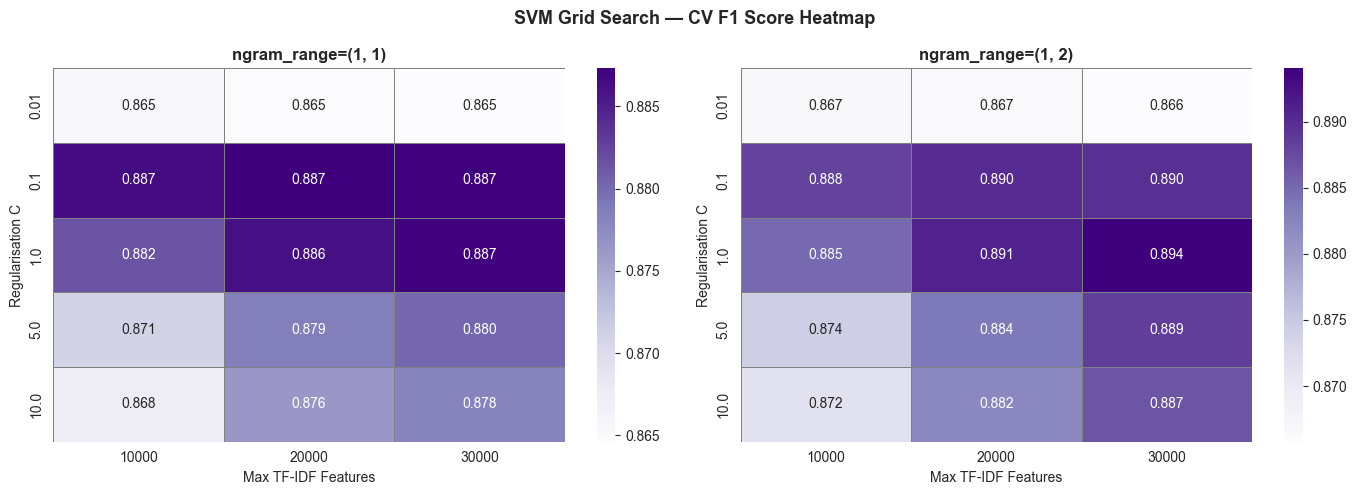

  Saved: gridsearch_heatmap_SVM.png


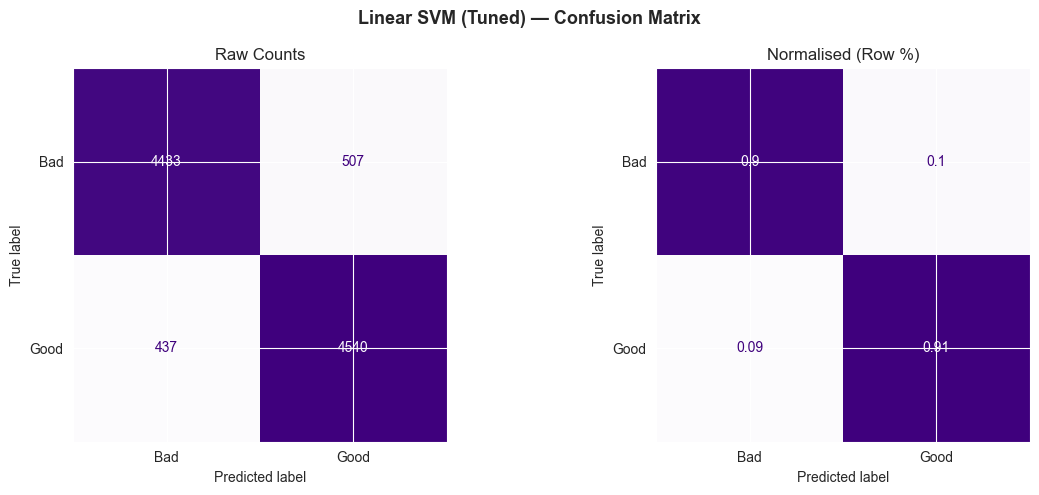

  Saved: confusion_matrix_SVM_tuned.png


In [120]:
print("\n")
print("=" * 60)
print("  LINEAR SVM MODEL")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
# SVM STEP 2 — FEATURE EXTRACTION FOR LINEAR SVM
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SVM STEP 2: TF-IDF Feature Extraction for Linear SVM")
print("=" * 60)

tfidf_svm = TfidfVectorizer(
    max_features=30000, ngram_range=(1, 2), min_df=3,
    max_df=0.95, sublinear_tf=True, stop_words=list(custom_stop_words)
)
X_train_svm = tfidf_svm.fit_transform(X_train)
X_val_svm   = tfidf_svm.transform(X_val)
X_test_svm  = tfidf_svm.transform(X_test)

print(f"  Vocabulary size    : {len(tfidf_svm.vocabulary_):,}")
print(f"  Train matrix shape : {X_train_svm.shape}")

# ─────────────────────────────────────────────────────────────
# SVM STEP 3 — TRAIN LINEAR SVM
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SVM STEP 3: Training Linear SVM")
print("=" * 60)

svm_model = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000, random_state=42), cv=3
)
svm_model.fit(X_train_svm, y_train)
print("  Training complete!")

# ─────────────────────────────────────────────────────────────
# SVM STEP 4 — VALIDATION RESULTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SVM STEP 4: Validation Set Results")
print("=" * 60)

svm_val_preds = svm_model.predict(X_val_svm)
svm_val_acc = accuracy_score(y_val, svm_val_preds)
svm_val_f1  = f1_score(y_val, svm_val_preds, average='weighted')
svm_val_pre = precision_score(y_val, svm_val_preds, average='weighted')
svm_val_rec = recall_score(y_val, svm_val_preds, average='weighted')

print(f"\n  Accuracy  : {svm_val_acc:.4f}  ({svm_val_acc*100:.2f}%)")
print(f"  F1 Score  : {svm_val_f1:.4f}")
print(f"  Precision : {svm_val_pre:.4f}")
print(f"  Recall    : {svm_val_rec:.4f}")
print(f"\n  Classification Report (Validation):")
print(classification_report(y_val, svm_val_preds, target_names=['Bad', 'Good']))

# ─────────────────────────────────────────────────────────────
# SVM STEP 5 — TEST SET RESULTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SVM STEP 5: Test Set Results  (Final Evaluation)")
print("=" * 60)

svm_test_preds = svm_model.predict(X_test_svm)
svm_test_acc = accuracy_score(y_test, svm_test_preds)
svm_test_f1  = f1_score(y_test, svm_test_preds, average='weighted')
svm_test_pre = precision_score(y_test, svm_test_preds, average='weighted')
svm_test_rec = recall_score(y_test, svm_test_preds, average='weighted')

print(f"\n  Accuracy  : {svm_test_acc:.4f}  ({svm_test_acc*100:.2f}%)")
print(f"  F1 Score  : {svm_test_f1:.4f}")
print(f"  Precision : {svm_test_pre:.4f}")
print(f"  Recall    : {svm_test_rec:.4f}")
print(f"\n  Classification Report (Test):")
print(classification_report(y_test, svm_test_preds, target_names=['Bad', 'Good']))

# ─────────────────────────────────────────────────────────────
# SVM STEP 6 — CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SVM STEP 6: Confusion Matrix")
print("=" * 60)

svm_cm = confusion_matrix(y_test, svm_test_preds, labels=['Bad', 'Good'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Linear SVM — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
ConfusionMatrixDisplay(svm_cm, display_labels=['Bad', 'Good']).plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Raw Counts')
svm_cm_norm = svm_cm.astype('float') / svm_cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(svm_cm_norm.round(2), display_labels=['Bad', 'Good']).plot(ax=axes[1], colorbar=False, cmap='Purples')
axes[1].set_title('Normalised (Row %)')
plt.tight_layout()
plt.savefig('confusion_matrix_SVM.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: confusion_matrix_SVM.png")

# ─────────────────────────────────────────────────────────────
# SVM STEP 7 — TOP FEATURES PER CLASS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SVM STEP 7: Top 15 Words Per Class")
print("=" * 60)

svm_features = tfidf_svm.get_feature_names_out()
svm_coef     = svm_model.calibrated_classifiers_[0].estimator.coef_[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Linear SVM — Top 15 Words Per Class', fontsize=13, fontweight='bold')
axes[0].barh(svm_features[np.argsort(svm_coef)[:15]],  svm_coef[np.argsort(svm_coef)[:15]],  color='#e74c3c', alpha=0.85)
axes[0].set_title('Top 15 Words → BAD',  fontweight='bold', color='#e74c3c')
axes[0].set_xlabel('SVM Coefficient Weight')
axes[1].barh(svm_features[np.argsort(svm_coef)[-15:]], svm_coef[np.argsort(svm_coef)[-15:]], color='#9b59b6', alpha=0.85)
axes[1].set_title('Top 15 Words → GOOD', fontweight='bold', color='#9b59b6')
axes[1].set_xlabel('SVM Coefficient Weight')
plt.tight_layout()
plt.savefig('top_features_SVM.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: top_features_SVM.png")

# ─────────────────────────────────────────────────────────────
# SVM STEP 8 — HYPERPARAMETER TUNING (Grid Search)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SVM STEP 8: Hyperparameter Tuning — Grid Search CV")
print("            90 combinations x 3 folds, please wait...")
print("=" * 60)

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=3, max_df=0.95, sublinear_tf=True,
                               stop_words=list(custom_stop_words))),
    ('svm', CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42), cv=3))
])
svm_param_grid = {
    'tfidf__max_features' : [10000, 20000, 30000],
    'tfidf__ngram_range'  : [(1, 1), (1, 2)],
    'svm__estimator__C'   : [0.01, 0.1, 1.0, 5.0, 10.0]      # ✅ new name
}
svm_grid = GridSearchCV(svm_pipeline, svm_param_grid, cv=cv,
                         scoring='f1_weighted', n_jobs=-1, verbose=1)
svm_grid.fit(X_train, y_train)

print(f"\n  ✅ Best CV F1 : {svm_grid.best_score_:.4f}")
print(f"  Best Params  :")
for p, v in svm_grid.best_params_.items():
    print(f"    {p:<35}: {v}")

best_svm_model  = svm_grid.best_estimator_
svm_tuned_preds = best_svm_model.predict(X_test)
svm_tuned_acc   = accuracy_score(y_test, svm_tuned_preds)
svm_tuned_f1    = f1_score(y_test, svm_tuned_preds, average='weighted')
svm_tuned_pre   = precision_score(y_test, svm_tuned_preds, average='weighted')
svm_tuned_rec   = recall_score(y_test, svm_tuned_preds, average='weighted')

print(f"\n  Before vs After Tuning (Test Set):")
print(f"  {'Metric':<12} {'Before':>10} {'After':>10} {'Change':>10}")
print(f"  {'-'*44}")
print(f"  {'Accuracy':<12} {svm_test_acc*100:>9.2f}% {svm_tuned_acc*100:>9.2f}% {(svm_tuned_acc-svm_test_acc)*100:>+9.2f}%")
print(f"  {'F1':<12} {svm_test_f1:>10.4f} {svm_tuned_f1:>10.4f} {svm_tuned_f1-svm_test_f1:>+10.4f}")
print(f"\n  Classification Report (Tuned SVM):")
print(classification_report(y_test, svm_tuned_preds, target_names=['Bad', 'Good']))

svm_cv_df = pd.DataFrame(svm_grid.cv_results_)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SVM Grid Search — CV F1 Score Heatmap', fontsize=13, fontweight='bold')
for ax, ngram in zip(axes, [(1, 1), (1, 2)]):
    mask   = svm_cv_df['param_tfidf__ngram_range'].apply(lambda x: x == ngram)
    subset = svm_cv_df[mask].copy()
    subset['C'] = subset['param_svm__estimator__C'].astype(float)
    subset['max_features'] = subset['param_tfidf__max_features'].astype(int)
    pivot  = subset.pivot_table(values='mean_test_score', index='C', columns='max_features')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Purples', ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'ngram_range={ngram}', fontweight='bold')
    ax.set_xlabel('Max TF-IDF Features')
    ax.set_ylabel('Regularisation C')
plt.tight_layout()
plt.savefig('gridsearch_heatmap_SVM.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: gridsearch_heatmap_SVM.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Linear SVM (Tuned) — Confusion Matrix', fontsize=13, fontweight='bold')
svm_cm_tuned = confusion_matrix(y_test, svm_tuned_preds, labels=['Bad', 'Good'])
ConfusionMatrixDisplay(svm_cm_tuned, display_labels=['Bad', 'Good']).plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Raw Counts')
svm_cm_tuned_norm = svm_cm_tuned.astype('float') / svm_cm_tuned.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(svm_cm_tuned_norm.round(2), display_labels=['Bad', 'Good']).plot(ax=axes[1], colorbar=False, cmap='Purples')
axes[1].set_title('Normalised (Row %)')
plt.tight_layout()
plt.savefig('confusion_matrix_SVM_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: confusion_matrix_SVM_tuned.png")

# SVM STEP 9 — LIVE PREDICTION (SVM)

In [122]:
print("\n" + "=" * 60)
print("SVM STEP 9: Live Prediction — Linear SVM (Tuned)")
print("            Type 'quit' to exit")
print("=" * 60)

def predict_svm(review_text):
    cleaned = clean_text(review_text)
    pred    = best_svm_model.predict([cleaned])[0]
    proba   = best_svm_model.predict_proba([cleaned])[0]
    print(f"\n  Review     : {review_text[:80]}{'...' if len(review_text) > 80 else ''}")
    print(f"  [SVM] Prediction : {'✅ GOOD' if pred == 'Good' else '❌ BAD'}")
    print(f"  Confidence :")
    for cls, prob in zip(best_svm_model.classes_, proba):
        print(f"    {cls:<6}: {prob*100:5.1f}%  {'█'*int(prob*30)}")

while True:
    print()
    user_input = input("Enter a review for SVM (or 'quit' to exit): ").strip()
    if user_input.lower() == 'quit':
        print("\n  SVM done! Ready for Random Forest model.")
        break
    if not user_input:
        print("  Please enter a review.")
        continue
    predict_svm(user_input)


SVM STEP 9: Live Prediction — Linear SVM (Tuned)
            Type 'quit' to exit


  Review     : this movie is good
  [SVM] Prediction : ✅ GOOD
  Confidence :
    Bad   :   6.7%  ██
    Good  :  93.3%  ███████████████████████████


  SVM done! Ready for Random Forest model.


# ╔════════════════════════════════════════════════════════════╗
# ║          MODEL 4 — RANDOM FOREST                          ║
# ╚════════════════════════════════════════════════════════════╝



  RANDOM FOREST MODEL

RF STEP 2: TF-IDF Feature Extraction for Random Forest
  Vocabulary size    : 10,000
  Train matrix shape : (29749, 10000)

RF STEP 3: Training Random Forest
  Training complete!

RF STEP 4: Validation Set Results

  Accuracy  : 0.8475  (84.75%)
  F1 Score  : 0.8473
  Precision : 0.8490
  Recall    : 0.8475

  Classification Report (Validation):
              precision    recall  f1-score   support

         Bad       0.87      0.81      0.84      4939
        Good       0.83      0.88      0.85      4977

    accuracy                           0.85      9916
   macro avg       0.85      0.85      0.85      9916
weighted avg       0.85      0.85      0.85      9916


RF STEP 5: Test Set Results  (Final Evaluation)

  Accuracy  : 0.8521  (85.21%)
  F1 Score  : 0.8520
  Precision : 0.8530
  Recall    : 0.8521

  Classification Report (Test):
              precision    recall  f1-score   support

         Bad       0.87      0.83      0.85      4940
        Good  

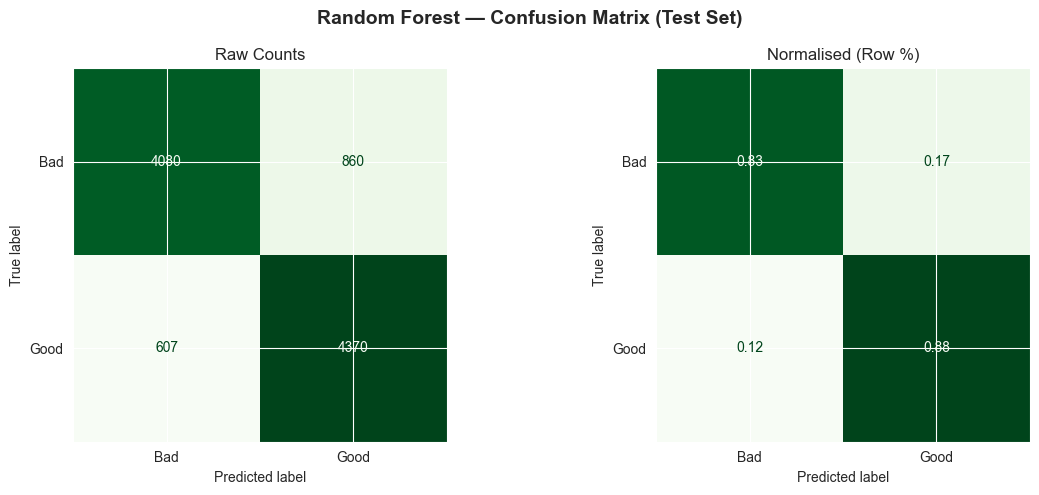

  Saved: confusion_matrix_RF.png

RF STEP 7: Top 15 Important Features


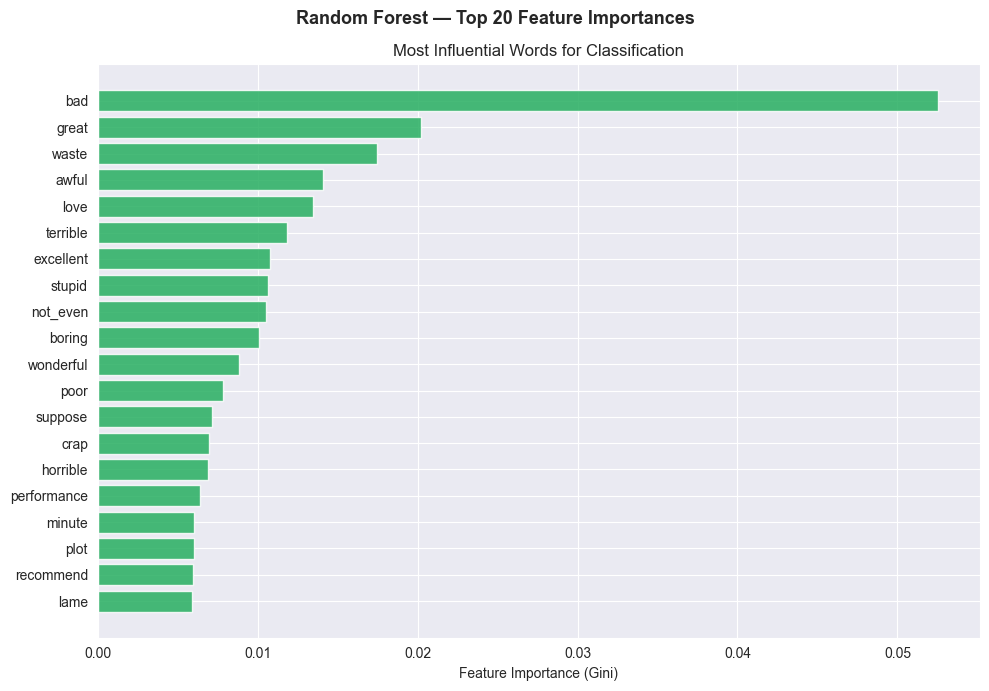

  Saved: top_features_RF.png

RF STEP 8: Hyperparameter Tuning — Grid Search CV
           54 combinations x 3 folds, please wait...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

  ✅ Grid Search Complete!
  Best CV F1 Score : 0.8532
  Best Parameters  :
    randomforestclassifier__max_depth            : None
    randomforestclassifier__n_estimators         : 300
    tfidf__max_features                          : 10000

  --- Before vs After Tuning (Test Set) ---
  Metric              Before      After     Change
  -----------------------------------------------
  Accuracy            85.21%     85.83%     +0.63%
  F1 Score            0.8520     0.8583    +0.0064
  Precision           0.8530     0.8583    +0.0054
  Recall              0.8521     0.8583    +0.0063

  Classification Report (Tuned RF — Test Set):
              precision    recall  f1-score   support

         Bad       0.86      0.85      0.86      4940
        Good       0.86      0.86      0.86      4977



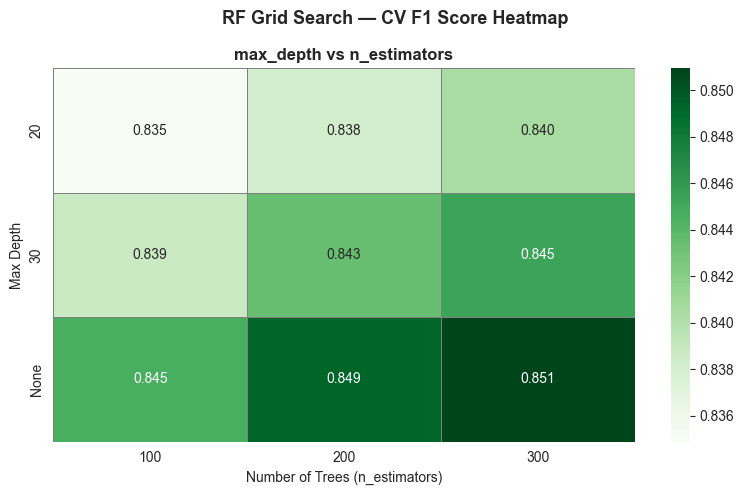

  Saved: gridsearch_heatmap_RF.png


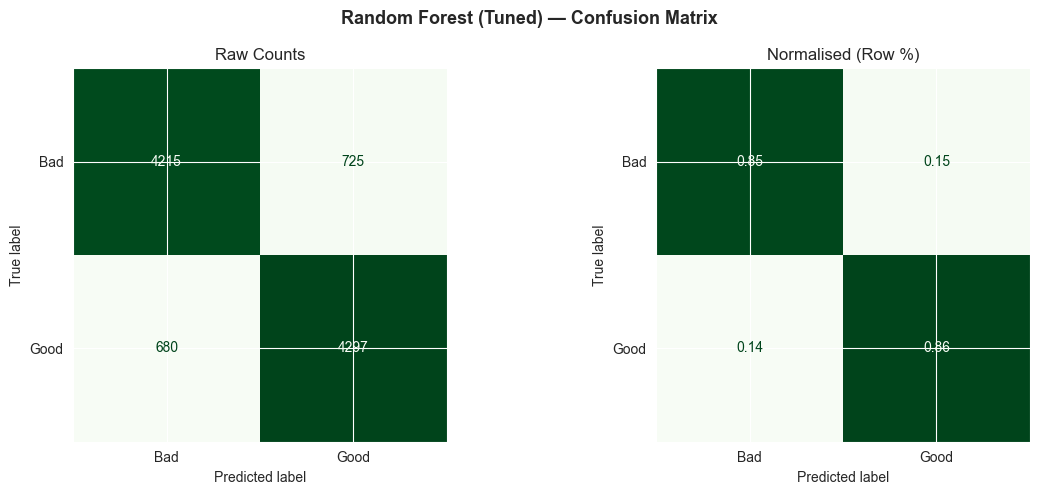

  Saved: confusion_matrix_RF_tuned.png


In [123]:
from sklearn.ensemble import RandomForestClassifier

print("\n")
print("=" * 60)
print("  RANDOM FOREST MODEL")
print("=" * 60)

# ─────────────────────────────────────────────────────────────
# RF STEP 2 — FEATURE EXTRACTION FOR RANDOM FOREST
#
# Random Forest gets its own TF-IDF vectorizer.
# Note: RF is a tree-based ensemble — it does NOT benefit
# from bigrams as much as linear models do, because trees
# split on individual features. We use unigrams only (1,1)
# for speed, then let grid search confirm the best setting.
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RF STEP 2: TF-IDF Feature Extraction for Random Forest")
print("=" * 60)

tfidf_rf = TfidfVectorizer(
    max_features = 10000,   # smaller vocab — RF is slower with large features
    ngram_range  = (1, 1),  # unigrams only for RF
    min_df       = 3,
    max_df       = 0.95,
    sublinear_tf = True,
    stop_words   = list(custom_stop_words)
)

X_train_rf = tfidf_rf.fit_transform(X_train)
X_val_rf   = tfidf_rf.transform(X_val)
X_test_rf  = tfidf_rf.transform(X_test)

print(f"  Vocabulary size    : {len(tfidf_rf.vocabulary_):,}")
print(f"  Train matrix shape : {X_train_rf.shape}")

# ─────────────────────────────────────────────────────────────
# RF STEP 3 — TRAIN RANDOM FOREST
#
# Key parameters:
#   n_estimators : number of trees — 200 gives good stability
#   max_depth    : limits tree depth to prevent overfitting
#   min_samples_split : min samples to split a node
#   n_jobs=-1    : use all CPU cores
#
# Why RF here?
#   RF is a non-linear ensemble model. It gives us a point
#   of comparison against the linear models (LR, SVM).
#   Papers like Khalid et al. (2022) show RF typically
#   scores lower than SVM on text data — we expect to see
#   this confirmed in our comparison.
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RF STEP 3: Training Random Forest")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 30,
    min_samples_split= 5,
    random_state     = 42,
    n_jobs           = -1
)
rf_model.fit(X_train_rf, y_train)
print("  Training complete!")

# ─────────────────────────────────────────────────────────────
# RF STEP 4 — VALIDATION RESULTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RF STEP 4: Validation Set Results")
print("=" * 60)

rf_val_preds = rf_model.predict(X_val_rf)
rf_val_acc   = accuracy_score(y_val, rf_val_preds)
rf_val_f1    = f1_score(y_val, rf_val_preds, average='weighted')
rf_val_pre   = precision_score(y_val, rf_val_preds, average='weighted')
rf_val_rec   = recall_score(y_val, rf_val_preds, average='weighted')

print(f"\n  Accuracy  : {rf_val_acc:.4f}  ({rf_val_acc*100:.2f}%)")
print(f"  F1 Score  : {rf_val_f1:.4f}")
print(f"  Precision : {rf_val_pre:.4f}")
print(f"  Recall    : {rf_val_rec:.4f}")
print(f"\n  Classification Report (Validation):")
print(classification_report(y_val, rf_val_preds, target_names=['Bad', 'Good']))

# ─────────────────────────────────────────────────────────────
# RF STEP 5 — TEST SET RESULTS
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RF STEP 5: Test Set Results  (Final Evaluation)")
print("=" * 60)

rf_test_preds = rf_model.predict(X_test_rf)
rf_test_acc   = accuracy_score(y_test, rf_test_preds)
rf_test_f1    = f1_score(y_test, rf_test_preds, average='weighted')
rf_test_pre   = precision_score(y_test, rf_test_preds, average='weighted')
rf_test_rec   = recall_score(y_test, rf_test_preds, average='weighted')

print(f"\n  Accuracy  : {rf_test_acc:.4f}  ({rf_test_acc*100:.2f}%)")
print(f"  F1 Score  : {rf_test_f1:.4f}")
print(f"  Precision : {rf_test_pre:.4f}")
print(f"  Recall    : {rf_test_rec:.4f}")
print(f"\n  Classification Report (Test):")
print(classification_report(y_test, rf_test_preds, target_names=['Bad', 'Good']))

# ─────────────────────────────────────────────────────────────
# RF STEP 6 — CONFUSION MATRIX
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RF STEP 6: Confusion Matrix")
print("=" * 60)

rf_cm = confusion_matrix(y_test, rf_test_preds, labels=['Bad', 'Good'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Random Forest — Confusion Matrix (Test Set)',
             fontsize=14, fontweight='bold')
ConfusionMatrixDisplay(rf_cm, display_labels=['Bad', 'Good']).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Raw Counts')
rf_cm_norm = rf_cm.astype('float') / rf_cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(rf_cm_norm.round(2), display_labels=['Bad', 'Good']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Normalised (Row %)')
plt.tight_layout()
plt.savefig('confusion_matrix_RF.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: confusion_matrix_RF.png")

# ─────────────────────────────────────────────────────────────
# RF STEP 7 — TOP FEATURES PER CLASS (Feature Importance)
#
# Unlike LR/SVM which use coefficients, RF uses
# feature_importances_ — how much each word reduces impurity.
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RF STEP 7: Top 15 Important Features")
print("=" * 60)

rf_features    = tfidf_rf.get_feature_names_out()
rf_importances = rf_model.feature_importances_
top_rf_idx     = np.argsort(rf_importances)[-20:]

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Random Forest — Top 20 Feature Importances',
             fontsize=13, fontweight='bold')
ax.barh(rf_features[top_rf_idx], rf_importances[top_rf_idx],
        color='#27ae60', alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Most Influential Words for Classification')
plt.tight_layout()
plt.savefig('top_features_RF.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: top_features_RF.png")

# ─────────────────────────────────────────────────────────────
# RF STEP 8 — HYPERPARAMETER TUNING (Grid Search)
#
# Parameters tuned:
#   tfidf__max_features        : vocabulary size
#   randomforestclassifier__n_estimators : number of trees
#   randomforestclassifier__max_depth    : tree depth limit
#
# Total: 2 x 3 x 3 = 18 combinations x 3 folds = 54 fits
# (smaller grid than LR/NB/SVM because RF is much slower)
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RF STEP 8: Hyperparameter Tuning — Grid Search CV")
print("           54 combinations x 3 folds, please wait...")
print("=" * 60)

rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 1), min_df=3, max_df=0.95,
        sublinear_tf=True, stop_words=list(custom_stop_words)
    )),
    ('randomforestclassifier', RandomForestClassifier(
        random_state=42, n_jobs=-1
    ))
])

rf_param_grid = {
    'tfidf__max_features'                      : [5000, 10000],
    'randomforestclassifier__n_estimators'     : [100, 200, 300],
    'randomforestclassifier__max_depth'        : [20, 30, None]
}

rf_grid_search = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
)
rf_grid_search.fit(X_train, y_train)

print(f"\n  ✅ Grid Search Complete!")
print(f"  Best CV F1 Score : {rf_grid_search.best_score_:.4f}")
print(f"  Best Parameters  :")
for param, value in rf_grid_search.best_params_.items():
    print(f"    {param:<45}: {value}")

best_rf_model  = rf_grid_search.best_estimator_
rf_tuned_preds = best_rf_model.predict(X_test)
rf_tuned_acc   = accuracy_score(y_test, rf_tuned_preds)
rf_tuned_f1    = f1_score(y_test, rf_tuned_preds, average='weighted')
rf_tuned_pre   = precision_score(y_test, rf_tuned_preds, average='weighted')
rf_tuned_rec   = recall_score(y_test, rf_tuned_preds, average='weighted')

print(f"\n  --- Before vs After Tuning (Test Set) ---")
print(f"  {'Metric':<15} {'Before':>10} {'After':>10} {'Change':>10}")
print(f"  {'-'*47}")
print(f"  {'Accuracy':<15} {rf_test_acc*100:>9.2f}% {rf_tuned_acc*100:>9.2f}%"
      f" {(rf_tuned_acc-rf_test_acc)*100:>+9.2f}%")
print(f"  {'F1 Score':<15} {rf_test_f1:>10.4f} {rf_tuned_f1:>10.4f}"
      f" {rf_tuned_f1-rf_test_f1:>+10.4f}")
print(f"  {'Precision':<15} {rf_test_pre:>10.4f} {rf_tuned_pre:>10.4f}"
      f" {rf_tuned_pre-rf_test_pre:>+10.4f}")
print(f"  {'Recall':<15} {rf_test_rec:>10.4f} {rf_tuned_rec:>10.4f}"
      f" {rf_tuned_rec-rf_test_rec:>+10.4f}")

print(f"\n  Classification Report (Tuned RF — Test Set):")
print(classification_report(y_test, rf_tuned_preds, target_names=['Bad', 'Good']))

# Grid Search Heatmap (n_estimators vs max_depth)
rf_cv_results = pd.DataFrame(rf_grid_search.cv_results_)

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('RF Grid Search — CV F1 Score Heatmap', fontsize=13, fontweight='bold')

subset_rf = rf_cv_results.copy()
subset_rf['n_estimators'] = subset_rf['param_randomforestclassifier__n_estimators'].astype(int)
subset_rf['max_depth']    = subset_rf['param_randomforestclassifier__max_depth'].astype(str)

pivot_rf = subset_rf.pivot_table(
    values='mean_test_score',
    index='max_depth',
    columns='n_estimators'
)
sns.heatmap(pivot_rf, annot=True, fmt='.3f', cmap='Greens',
            ax=ax, linewidths=0.5, linecolor='gray')
ax.set_title('max_depth vs n_estimators', fontweight='bold')
ax.set_xlabel('Number of Trees (n_estimators)')
ax.set_ylabel('Max Depth')
plt.tight_layout()
plt.savefig('gridsearch_heatmap_RF.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: gridsearch_heatmap_RF.png")

# Tuned Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Random Forest (Tuned) — Confusion Matrix', fontsize=13, fontweight='bold')
rf_cm_tuned = confusion_matrix(y_test, rf_tuned_preds, labels=['Bad', 'Good'])
ConfusionMatrixDisplay(rf_cm_tuned, display_labels=['Bad', 'Good']).plot(
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Raw Counts')
rf_cm_tuned_norm = rf_cm_tuned.astype('float') / rf_cm_tuned.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(rf_cm_tuned_norm.round(2), display_labels=['Bad', 'Good']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Normalised (Row %)')
plt.tight_layout()
plt.savefig('confusion_matrix_RF_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: confusion_matrix_RF_tuned.png")

# RF STEP 9 — LIVE PREDICTION (RF)

In [124]:
print("\n" + "=" * 60)
print("RF STEP 9: Live Prediction — Random Forest (Tuned)")
print("           Type 'quit' to exit")
print("=" * 60)

def predict_rf(review_text):
    cleaned = clean_text(review_text)
    pred    = best_rf_model.predict([cleaned])[0]
    proba   = best_rf_model.predict_proba([cleaned])[0]
    print(f"\n  Review     : {review_text[:80]}{'...' if len(review_text) > 80 else ''}")
    print(f"  [RF] Prediction : {'✅ GOOD' if pred == 'Good' else '❌ BAD'}")
    print(f"  Confidence :")
    for cls, prob in zip(best_rf_model.classes_, proba):
        print(f"    {cls:<6}: {prob*100:5.1f}%  {'█'*int(prob*30)}")

while True:
    print()
    user_input = input("Enter a review for RF (or 'quit' to exit): ").strip()
    if user_input.lower() == 'quit':
        print("\n  RF done! Moving to final comparison...")
        break
    if not user_input:
        print("  Please enter a review.")
        continue
    predict_rf(user_input)


RF STEP 9: Live Prediction — Random Forest (Tuned)
           Type 'quit' to exit


  Review     : this is good movie
  [RF] Prediction : ✅ GOOD
  Confidence :
    Bad   :  14.3%  ████
    Good  :  85.7%  █████████████████████████


  RF done! Moving to final comparison...


# ╔════════════════════════════════════════════════════════════╗
# ║     FINAL COMPARISON — ALL 4 MODELS                       ║
# ╚════════════════════════════════════════════════════════════╝



████████████████████████████████████████████████████████████
█  FINAL COMPARISON — LR vs NB vs SVM vs RF
████████████████████████████████████████████████████████████


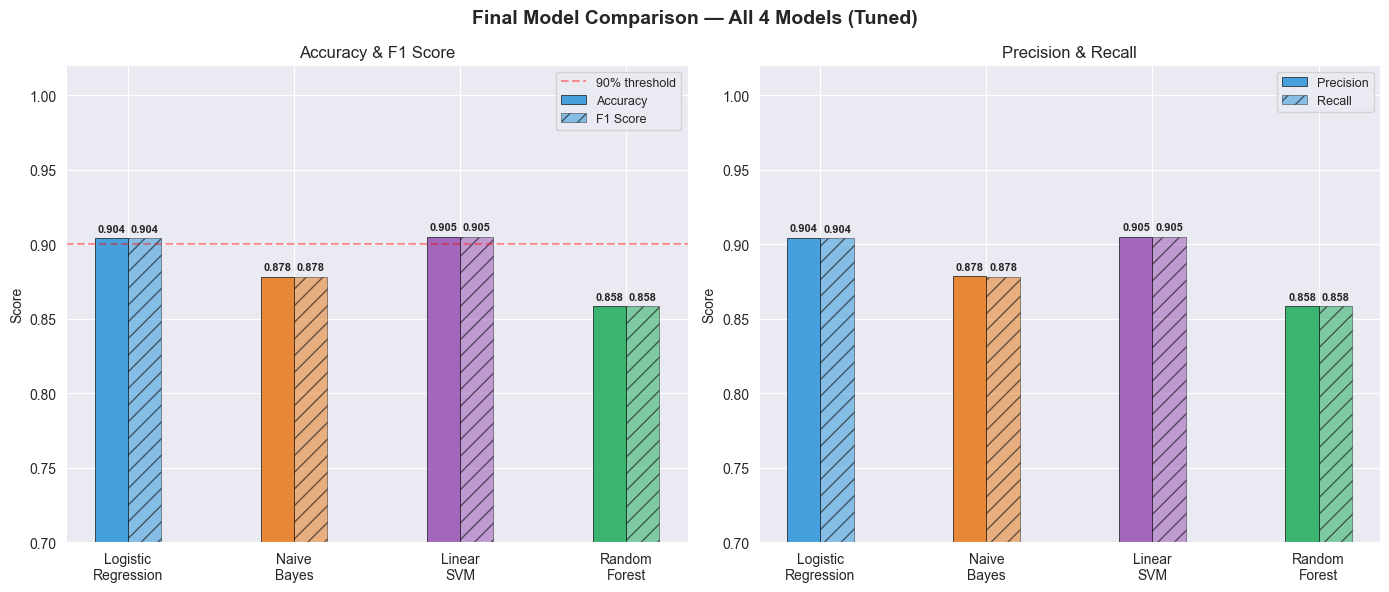

  Saved: comparison_all_4_models.png


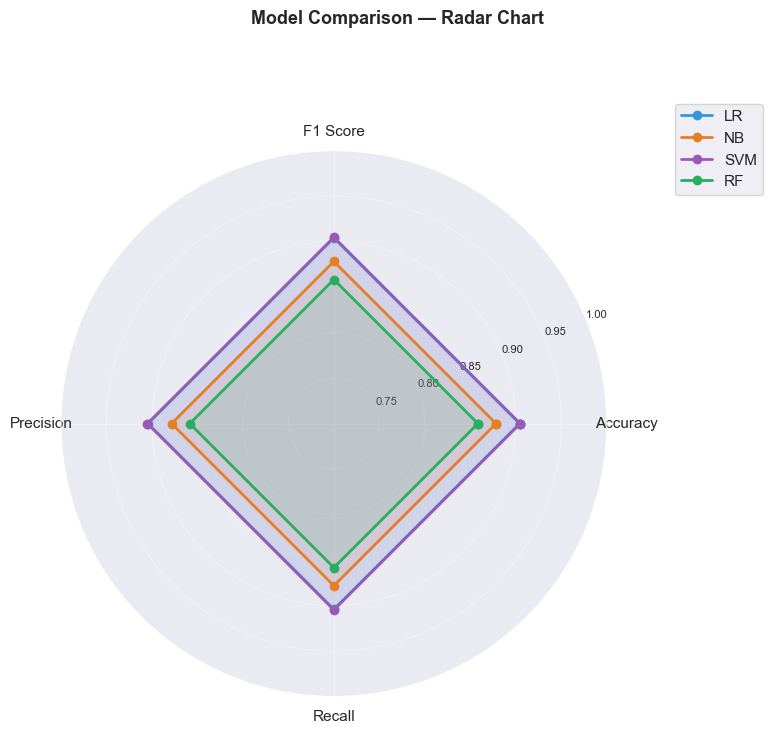

  Saved: radar_chart_all_models.png

  FINAL RESULTS SUMMARY — All 4 Models (After Tuning)
  Model                    Accuracy         F1  Precision     Recall
  --------------------------------------------------------------
  Logistic Regression        90.41%     0.9041     0.9042     0.9041
  Naive Bayes                87.82%     0.8782     0.8783     0.8782
  Linear SVM                 90.48%     0.9048     0.9049     0.9048
  Random Forest              85.83%     0.8583     0.8583     0.8583

  🏆 Best Model  (F1) : Linear SVM  (0.9048)
  📉 Lowest Model (F1): Random Forest  (0.8583)

  ✅ All 4 models complete!
  Run bonus_absa.py next for aspect-based sentiment analysis.


In [125]:
print("\n")
print("█" * 60)
print("█  FINAL COMPARISON — LR vs NB vs SVM vs RF")
print("█" * 60)

# ─────────────────────────────────────────────────────────────
# Collect tuned results from all 4 models
# These variables were set during each model's grid search:
#   tuned_acc / tuned_f1 / tuned_pre / tuned_rec   → LR
#   nb_tuned_acc / nb_tuned_f1 / ...               → NB
#   svm_tuned_acc / svm_tuned_f1 / ...             → SVM
#   rf_tuned_acc / rf_tuned_f1 / ...               → RF
# ─────────────────────────────────────────────────────────────
model_names = [
    'Logistic\nRegression',
    'Naive\nBayes',
    'Linear\nSVM',
    'Random\nForest'
]
accuracies = [tuned_acc,    nb_tuned_acc,  svm_tuned_acc,  rf_tuned_acc]
f1_scores  = [tuned_f1,     nb_tuned_f1,   svm_tuned_f1,   rf_tuned_f1]
precisions = [tuned_pre,    nb_tuned_pre,  svm_tuned_pre,  rf_tuned_pre]
recalls    = [tuned_rec,    nb_tuned_rec,  svm_tuned_rec,  rf_tuned_rec]
colors     = ['#3498db',   '#e67e22',     '#9b59b6',      '#27ae60']

x     = np.arange(len(model_names))
width = 0.20

# ─── Plot 1: Accuracy & F1 ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Final Model Comparison — All 4 Models (Tuned)',
             fontsize=14, fontweight='bold')

bars1 = axes[0].bar(x - width/2, accuracies, width,
                    label='Accuracy', color=colors, alpha=0.90,
                    edgecolor='black', linewidth=0.5)
bars2 = axes[0].bar(x + width/2, f1_scores, width,
                    label='F1 Score', color=colors, alpha=0.55,
                    edgecolor='black', linewidth=0.5, hatch='//')

for bar, val in zip(list(bars1) + list(bars2), accuracies + f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=8, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].set_ylim(0.70, 1.02)
axes[0].set_ylabel('Score')
axes[0].set_title('Accuracy & F1 Score')
axes[0].axhline(0.90, color='red', linestyle='--', alpha=0.4, label='90% threshold')
axes[0].legend(fontsize=9)

# ─── Plot 2: Precision & Recall ──────────────────────────────
bars3 = axes[1].bar(x - width/2, precisions, width,
                    label='Precision', color=colors, alpha=0.90,
                    edgecolor='black', linewidth=0.5)
bars4 = axes[1].bar(x + width/2, recalls, width,
                    label='Recall', color=colors, alpha=0.55,
                    edgecolor='black', linewidth=0.5, hatch='//')

for bar, val in zip(list(bars3) + list(bars4), precisions + recalls):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=8, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=10)
axes[1].set_ylim(0.70, 1.02)
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('comparison_all_4_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: comparison_all_4_models.png")

# ─── Radar Chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Model Comparison — Radar Chart', fontsize=13, fontweight='bold')

metrics      = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
num_metrics  = len(metrics)
angles       = [n / float(num_metrics) * 2 * np.pi for n in range(num_metrics)]
angles      += angles[:1]

model_scores = [
    [tuned_acc,   tuned_f1,    tuned_pre,   tuned_rec],
    [nb_tuned_acc,nb_tuned_f1, nb_tuned_pre,nb_tuned_rec],
    [svm_tuned_acc,svm_tuned_f1,svm_tuned_pre,svm_tuned_rec],
    [rf_tuned_acc, rf_tuned_f1, rf_tuned_pre, rf_tuned_rec]
]
short_names = ['LR', 'NB', 'SVM', 'RF']

for scores, color, name in zip(model_scores, colors, short_names):
    values  = scores + scores[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, values, alpha=0.10, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.7, 1.0)
ax.set_yticks([0.75, 0.80, 0.85, 0.90, 0.95, 1.00])
ax.set_yticklabels(['0.75','0.80','0.85','0.90','0.95','1.00'], fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('radar_chart_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: radar_chart_all_models.png")

# ─── Final Summary Table ──────────────────────────────────────
print("\n" + "=" * 65)
print("  FINAL RESULTS SUMMARY — All 4 Models (After Tuning)")
print("=" * 65)
print(f"  {'Model':<22} {'Accuracy':>10} {'F1':>10} {'Precision':>10} {'Recall':>10}")
print(f"  {'-'*62}")

for name, acc, f1, pre, rec in zip(
    ['Logistic Regression', 'Naive Bayes', 'Linear SVM', 'Random Forest'],
    accuracies, f1_scores, precisions, recalls
):
    print(f"  {name:<22} {acc*100:>9.2f}% {f1:>10.4f} {pre:>10.4f} {rec:>10.4f}")

best_idx  = int(np.argmax(f1_scores))
worst_idx = int(np.argmin(f1_scores))
best_name  = ['Logistic Regression','Naive Bayes','Linear SVM','Random Forest'][best_idx]
worst_name = ['Logistic Regression','Naive Bayes','Linear SVM','Random Forest'][worst_idx]

print(f"\n  🏆 Best Model  (F1) : {best_name}  ({f1_scores[best_idx]:.4f})")
print(f"  📉 Lowest Model (F1): {worst_name}  ({f1_scores[worst_idx]:.4f})")
print("=" * 65)
print("\n  ✅ All 4 models complete!")
print("  Run bonus_absa.py next for aspect-based sentiment analysis.")

In [126]:
import joblib
joblib.dump(best_svm_model, 'best_model.pkl')
print("✅ Model saved as best_model.pkl")

✅ Model saved as best_model.pkl
